In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc
from matplotlib.patches import Patch

In [ ]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [ ]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_W = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_W.npy')

wrf_rel = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_rel.npy')
wrf_vax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vax.npy')
wrf_vtn = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vtn.npy')
wrf_cax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cax.npy')
wrf_cot = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cot.npy')
wrf_ind = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_ind.npy')
wrf_thr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_thr.npy')
wrf_pow = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_pow.npy')
shapiro = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

wrf_CD   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CD.npy')
wrf_CL   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CL.npy')
wrf_phi   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_phi.npy')

wrf_L   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_L.npy')
wrf_D   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_D.npy')

In [ ]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [ ]:
# Define the specific equation (e.g., linear: y = a * x + b)
def madsen_func(CT, a, b, c):

    return a * CT**3 + b * CT**2 + c * CT

In [ ]:
veer  = np.array([-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

indices_n80 = [i for i, (s, v) in enumerate(training) if (v == -80 and abs(s) == 0)]
indices_n40 = [i for i, (s, v) in enumerate(training) if (v == -40 and abs(s) == 0)]
indices_n20 = [i for i, (s, v) in enumerate(training) if (v == -20 and abs(s) == 0)]
indices_n10 = [i for i, (s, v) in enumerate(training) if (v == -10 and abs(s) == 0)]
indices_00 = [i for i, (s, v) in enumerate(training) if (v == 0 and abs(s) == 0)]
indices_10 = [i for i, (s, v) in enumerate(training) if (v == 10 and abs(s) == 0)]
indices_20 = [i for i, (s, v) in enumerate(training) if (v == 20 and abs(s) == 0)]
indices_40 = [i for i, (s, v) in enumerate(training) if (v == 40 and abs(s) == 0)]
indices_80 = [i for i, (s, v) in enumerate(training) if (v == 80 and abs(s) == 0)]

In [ ]:
# V80

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_80])
ct_mom = np.append(ct_mom, wrf_cot[indices_80])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_v80, b_fit_v80, c_fit_v80 = params

x_fit_v80 = np.linspace(0, 2, 100)
y_fit_v80 = madsen_func(x_fit_v80, a_fit_v80, b_fit_v80, c_fit_v80)

In [ ]:
# V40

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_40])
ct_mom = np.append(ct_mom, wrf_cot[indices_40])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_v40, b_fit_v40, c_fit_v40 = params

x_fit_v40 = np.linspace(0, 2, 100)
y_fit_v40 = madsen_func(x_fit_v40, a_fit_v40, b_fit_v40, c_fit_v40)

In [ ]:
# V20

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_20])
ct_mom = np.append(ct_mom, wrf_cot[indices_20])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_v20, b_fit_v20, c_fit_v20 = params

x_fit_v20 = np.linspace(0, 2, 100)
y_fit_v20 = madsen_func(x_fit_v20, a_fit_v20, b_fit_v20, c_fit_v20)

In [ ]:
# V10

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_10])
ct_mom = np.append(ct_mom, wrf_cot[indices_10])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_v10, b_fit_v10, c_fit_v10 = params

x_fit_v10 = np.linspace(0, 2, 100)
y_fit_v10 = madsen_func(x_fit_v10, a_fit_v10, b_fit_v10, c_fit_v10)

In [ ]:
# V0

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_00])
ct_mom = np.append(ct_mom, wrf_cot[indices_00])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_v00, b_fit_v00, c_fit_v00 = params

x_fit_v00 = np.linspace(0, 2, 100)
y_fit_v00 = madsen_func(x_fit_v00, a_fit_v00, b_fit_v00, c_fit_v00)

In [ ]:
# Vn10

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_n10])
ct_mom = np.append(ct_mom, wrf_cot[indices_n10])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_vn10, b_fit_vn10, c_fit_vn10 = params

x_fit_vn10 = np.linspace(0, 2, 100)
y_fit_vn10 = madsen_func(x_fit_vn10, a_fit_vn10, b_fit_vn10, c_fit_vn10)

In [ ]:
# Vn20

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_n20])
ct_mom = np.append(ct_mom, wrf_cot[indices_n20])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_vn20, b_fit_vn20, c_fit_vn20 = params

x_fit_vn20 = np.linspace(0, 2, 100)
y_fit_vn20 = madsen_func(x_fit_vn20, a_fit_vn20, b_fit_vn20, c_fit_vn20)

In [ ]:
# Vn40

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_n40])
ct_mom = np.append(ct_mom, wrf_cot[indices_n40])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_vn40, b_fit_vn40, c_fit_vn40 = params

x_fit_vn40 = np.linspace(0, 2, 100)
y_fit_vn40 = madsen_func(x_fit_vn40, a_fit_vn40, b_fit_vn40, c_fit_vn40)

In [ ]:
# Vn80

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_n80])
ct_mom = np.append(ct_mom, wrf_cot[indices_n80])

params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

a_fit_vn80, b_fit_vn80, c_fit_vn80 = params

x_fit_vn80 = np.linspace(0, 2, 100)
y_fit_vn80 = madsen_func(x_fit_vn80, a_fit_vn80, b_fit_vn80, c_fit_vn80)

In [17]:
print("if int(self.veer) == -8:")
print(f"    a,b,c = {a_fit_vn80:.4f}, {b_fit_vn80:.4f}, {c_fit_vn80:.4f}")
print("elif int(self.veer) == -4:")
print(f"    a,b,c = {a_fit_vn40:.4f}, {b_fit_vn40:.4f}, {c_fit_vn40:.4f}")
print("elif int(self.veer) == -2:")
print(f"    a,b,c = {a_fit_vn20:.4f}, {b_fit_vn20:.4f}, {c_fit_vn20:.4f}")
print("elif int(self.veer) == -1:")
print(f"    a,b,c = {a_fit_vn10:.4f}, {b_fit_vn10:.4f}, {c_fit_vn10:.4f}")
print("elif int(self.veer) == 0:")
print(f"    a,b,c = {a_fit_v00:.4f}, {b_fit_v00:.4f}, {c_fit_v00:.4f}")
print("elif int(self.veer) == 1:")
print(f"    a,b,c = {a_fit_v10:.4f}, {b_fit_v10:.4f}, {c_fit_v10:.4f}")
print("elif int(self.veer) == 2:")
print(f"    a,b,c = {a_fit_v20:.4f}, {b_fit_v20:.4f}, {c_fit_v20:.4f}")
print("elif int(self.veer) == 4:")
print(f"    a,b,c = {a_fit_v40:.4f}, {b_fit_v40:.4f}, {c_fit_v40:.4f}")
print("elif int(self.veer) == 8:")
print(f"    a,b,c = {a_fit_v80:.4f}, {b_fit_v80:.4f}, {c_fit_v80:.4f}")

if int(self.veer) == -8:
    a,b,c = 0.1782, 0.0251, 0.2522
elif int(self.veer) == -4:
    a,b,c = 0.1278, 0.0384, 0.2514
elif int(self.veer) == -2:
    a,b,c = 0.1084, 0.0435, 0.2511
elif int(self.veer) == -1:
    a,b,c = 0.1040, 0.0446, 0.2510
elif int(self.veer) == 0:
    a,b,c = 0.1043, 0.0445, 0.2510
elif int(self.veer) == 1:
    a,b,c = 0.1099, 0.0431, 0.2511
elif int(self.veer) == 2:
    a,b,c = 0.1205, 0.0403, 0.2513
elif int(self.veer) == 4:
    a,b,c = 0.1535, 0.0316, 0.2518
elif int(self.veer) == 8:
    a,b,c = 0.2274, 0.0122, 0.2529


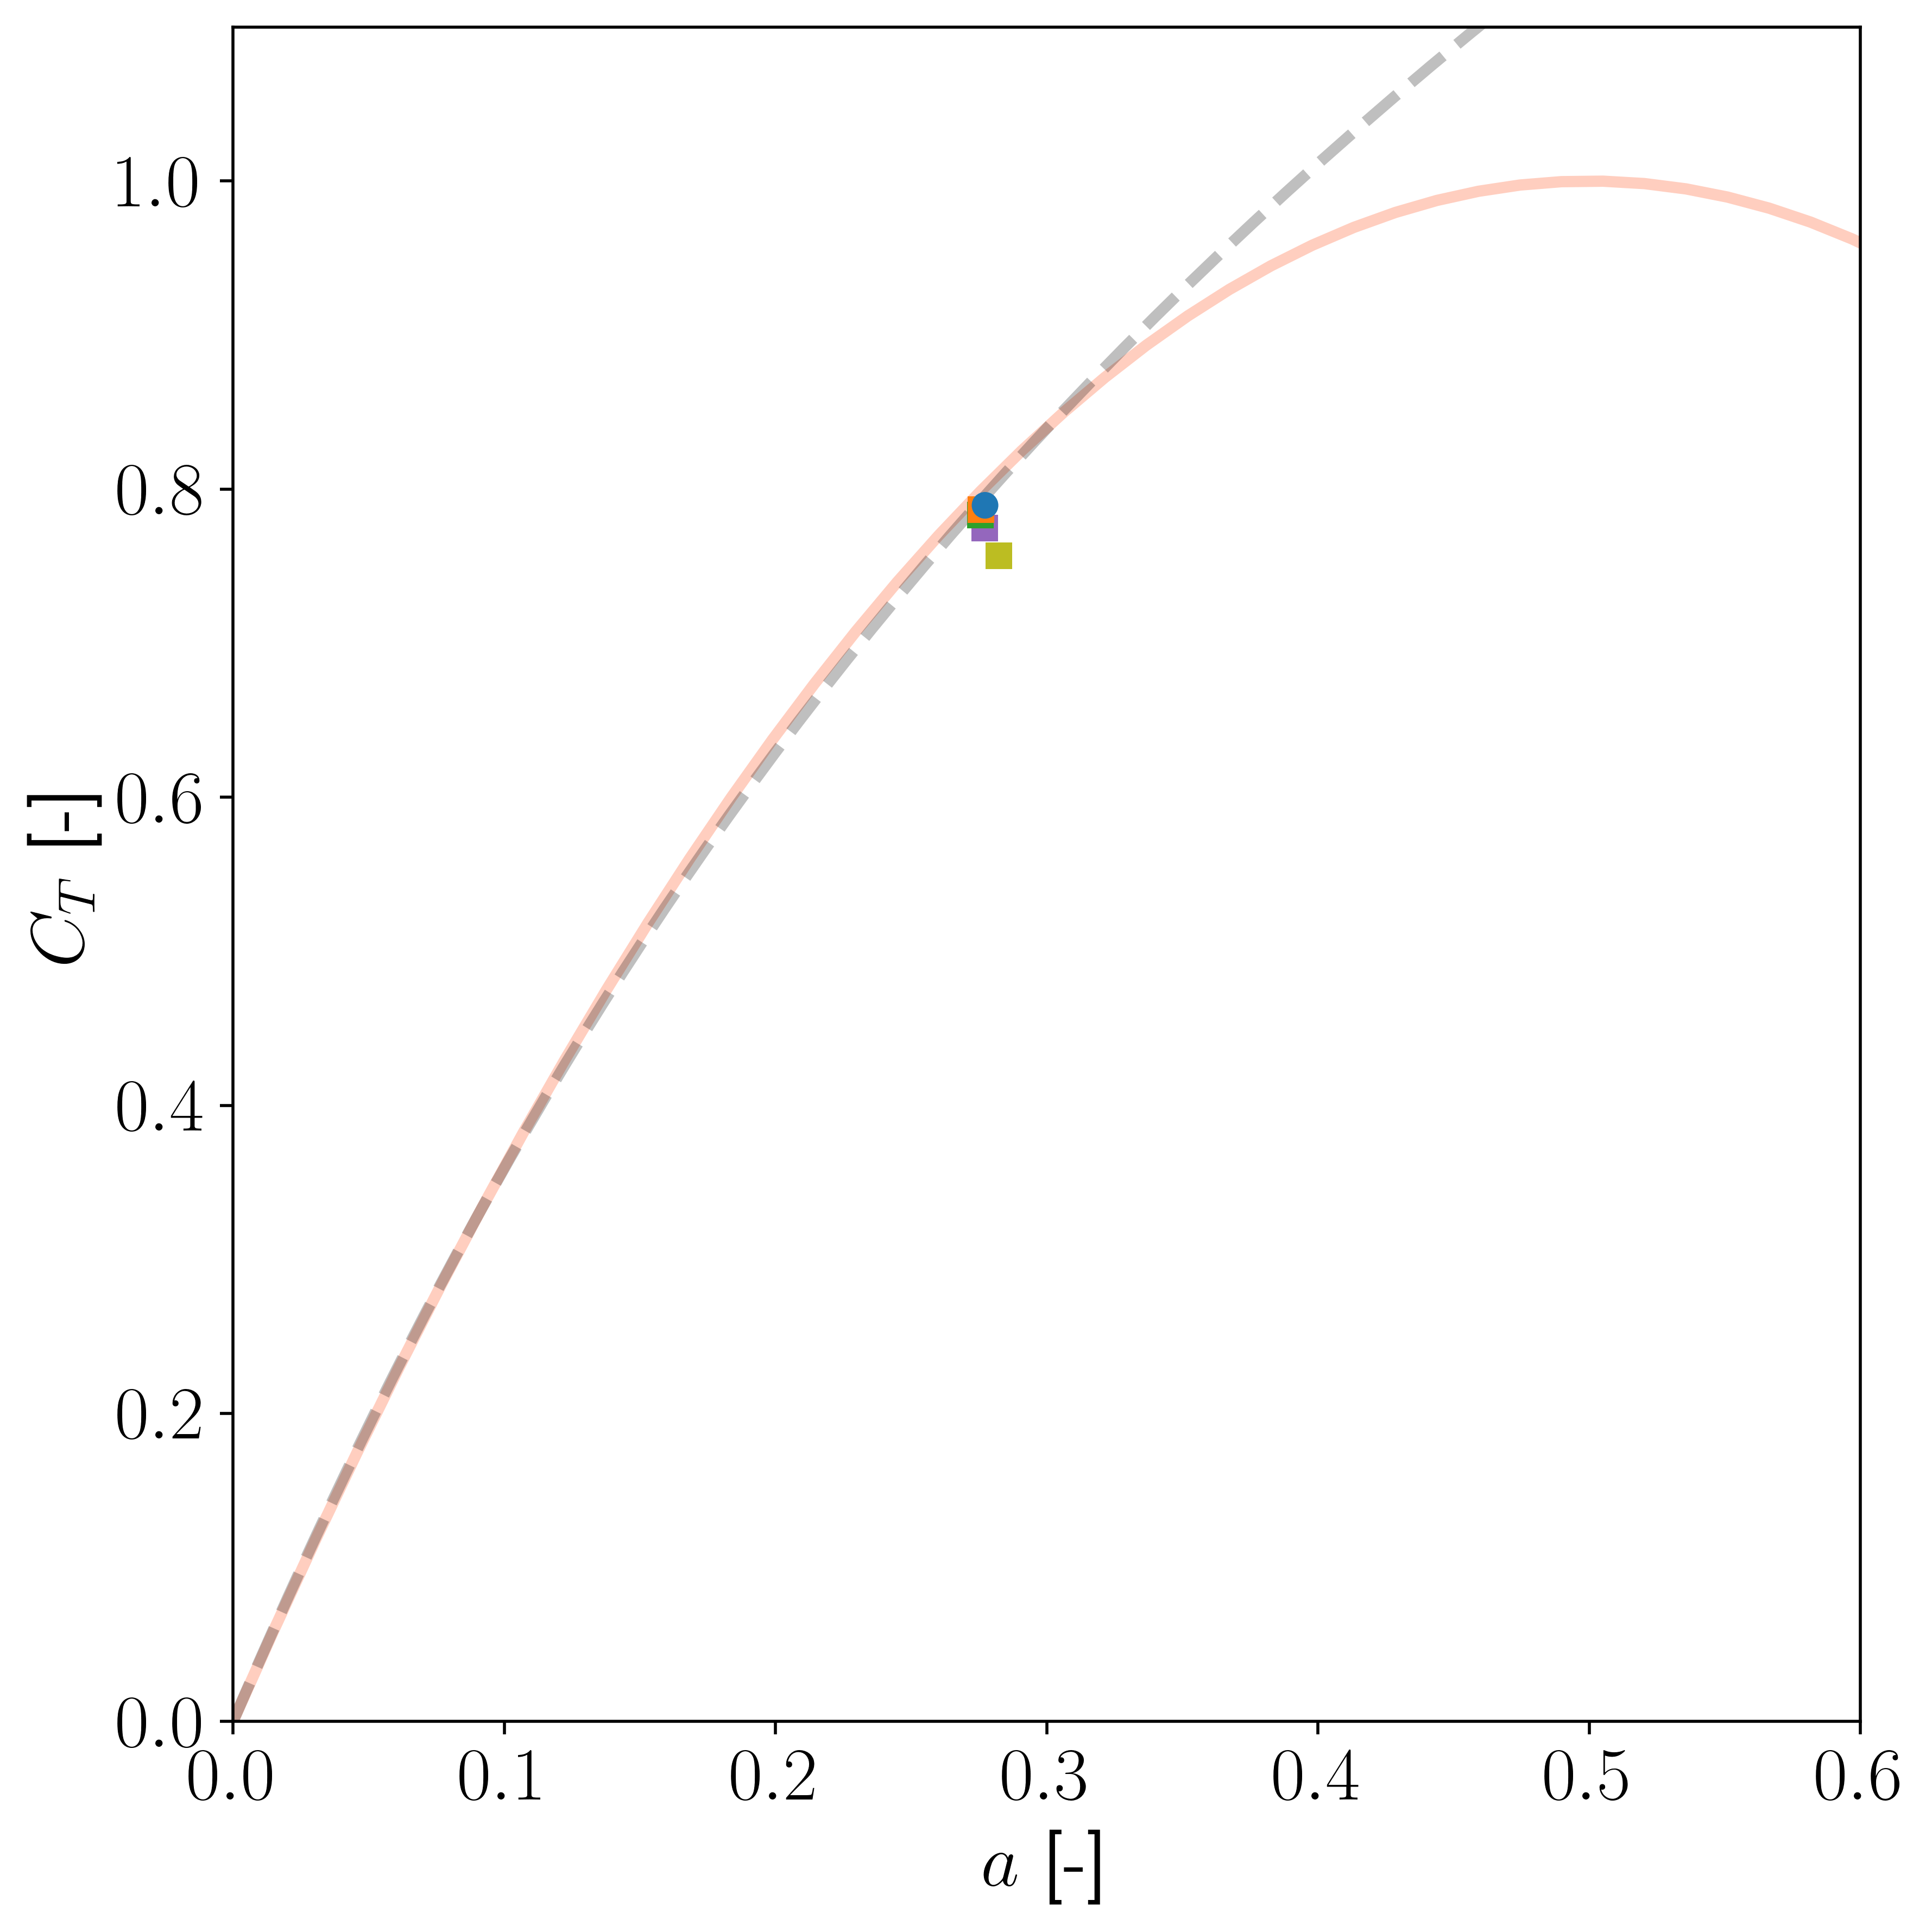

In [18]:
colors = sns.color_palette("tab10", 9)
# colors = colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

# ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
# ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$-10$')
# ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$-20$')
# ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$-40$')
# ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$-80$')

# ax.set_xlim([0.2,0.4])
# ax.set_ylim([0.5,1.0])

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

mesh = ax.scatter(wrf_ind[indices_n80], wrf_cot[indices_n80], marker='s', s=50, edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(wrf_ind[indices_n40], wrf_cot[indices_n40], marker='s', s=50, edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(wrf_ind[indices_n20], wrf_cot[indices_n20], marker='s', s=50, edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(wrf_ind[indices_n10], wrf_cot[indices_n10], marker='s', s=50, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(wrf_ind[indices_00], wrf_cot[indices_00], s=50, edgecolor='none',color=colors[0],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_10], wrf_cot[indices_10], s=50, edgecolor='none',color=colors[1],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_20], wrf_cot[indices_20], s=50, edgecolor='none',color=colors[2],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_40], wrf_cot[indices_40], s=50, edgecolor='none',color=colors[4],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_80], wrf_cot[indices_80], s=50, edgecolor='none',color=colors[8],zorder=3)

# mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',label='WRF-LES')

# ax.legend(title='$\Delta \\beta$ [deg]')

# fig.text(0.55,0.40, f'Coefficients with Shapiro correction:', ha='left', fontsize=12,rotation=0,color='k')
# fig.text(0.55,0.35, f'$a = {a_fit_v00:0.3f}C_T^3 + {b_fit_v00:0.3f}C_T^2 + {c_fit_v00:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[0])
# fig.text(0.55,0.30, f'$a = {a_fit_v10:0.3f}C_T^3 + {b_fit_v10:0.3f}C_T^2 + {c_fit_v10:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[1])
# fig.text(0.55,0.25, f'$a = {a_fit_v20:0.3f}C_T^3 + {b_fit_v20:0.3f}C_T^2 + {c_fit_v20:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[2])
# fig.text(0.55,0.20, f'$a = {a_fit_v40:0.3f}C_T^3 + {b_fit_v40:0.3f}C_T^2 + {c_fit_v40:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[4])
# fig.text(0.55,0.15, f'$a = {a_fit_v80:0.3f}C_T^3 + {b_fit_v80:0.3f}C_T^2 + {c_fit_v80:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[8])

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)

plt.show()

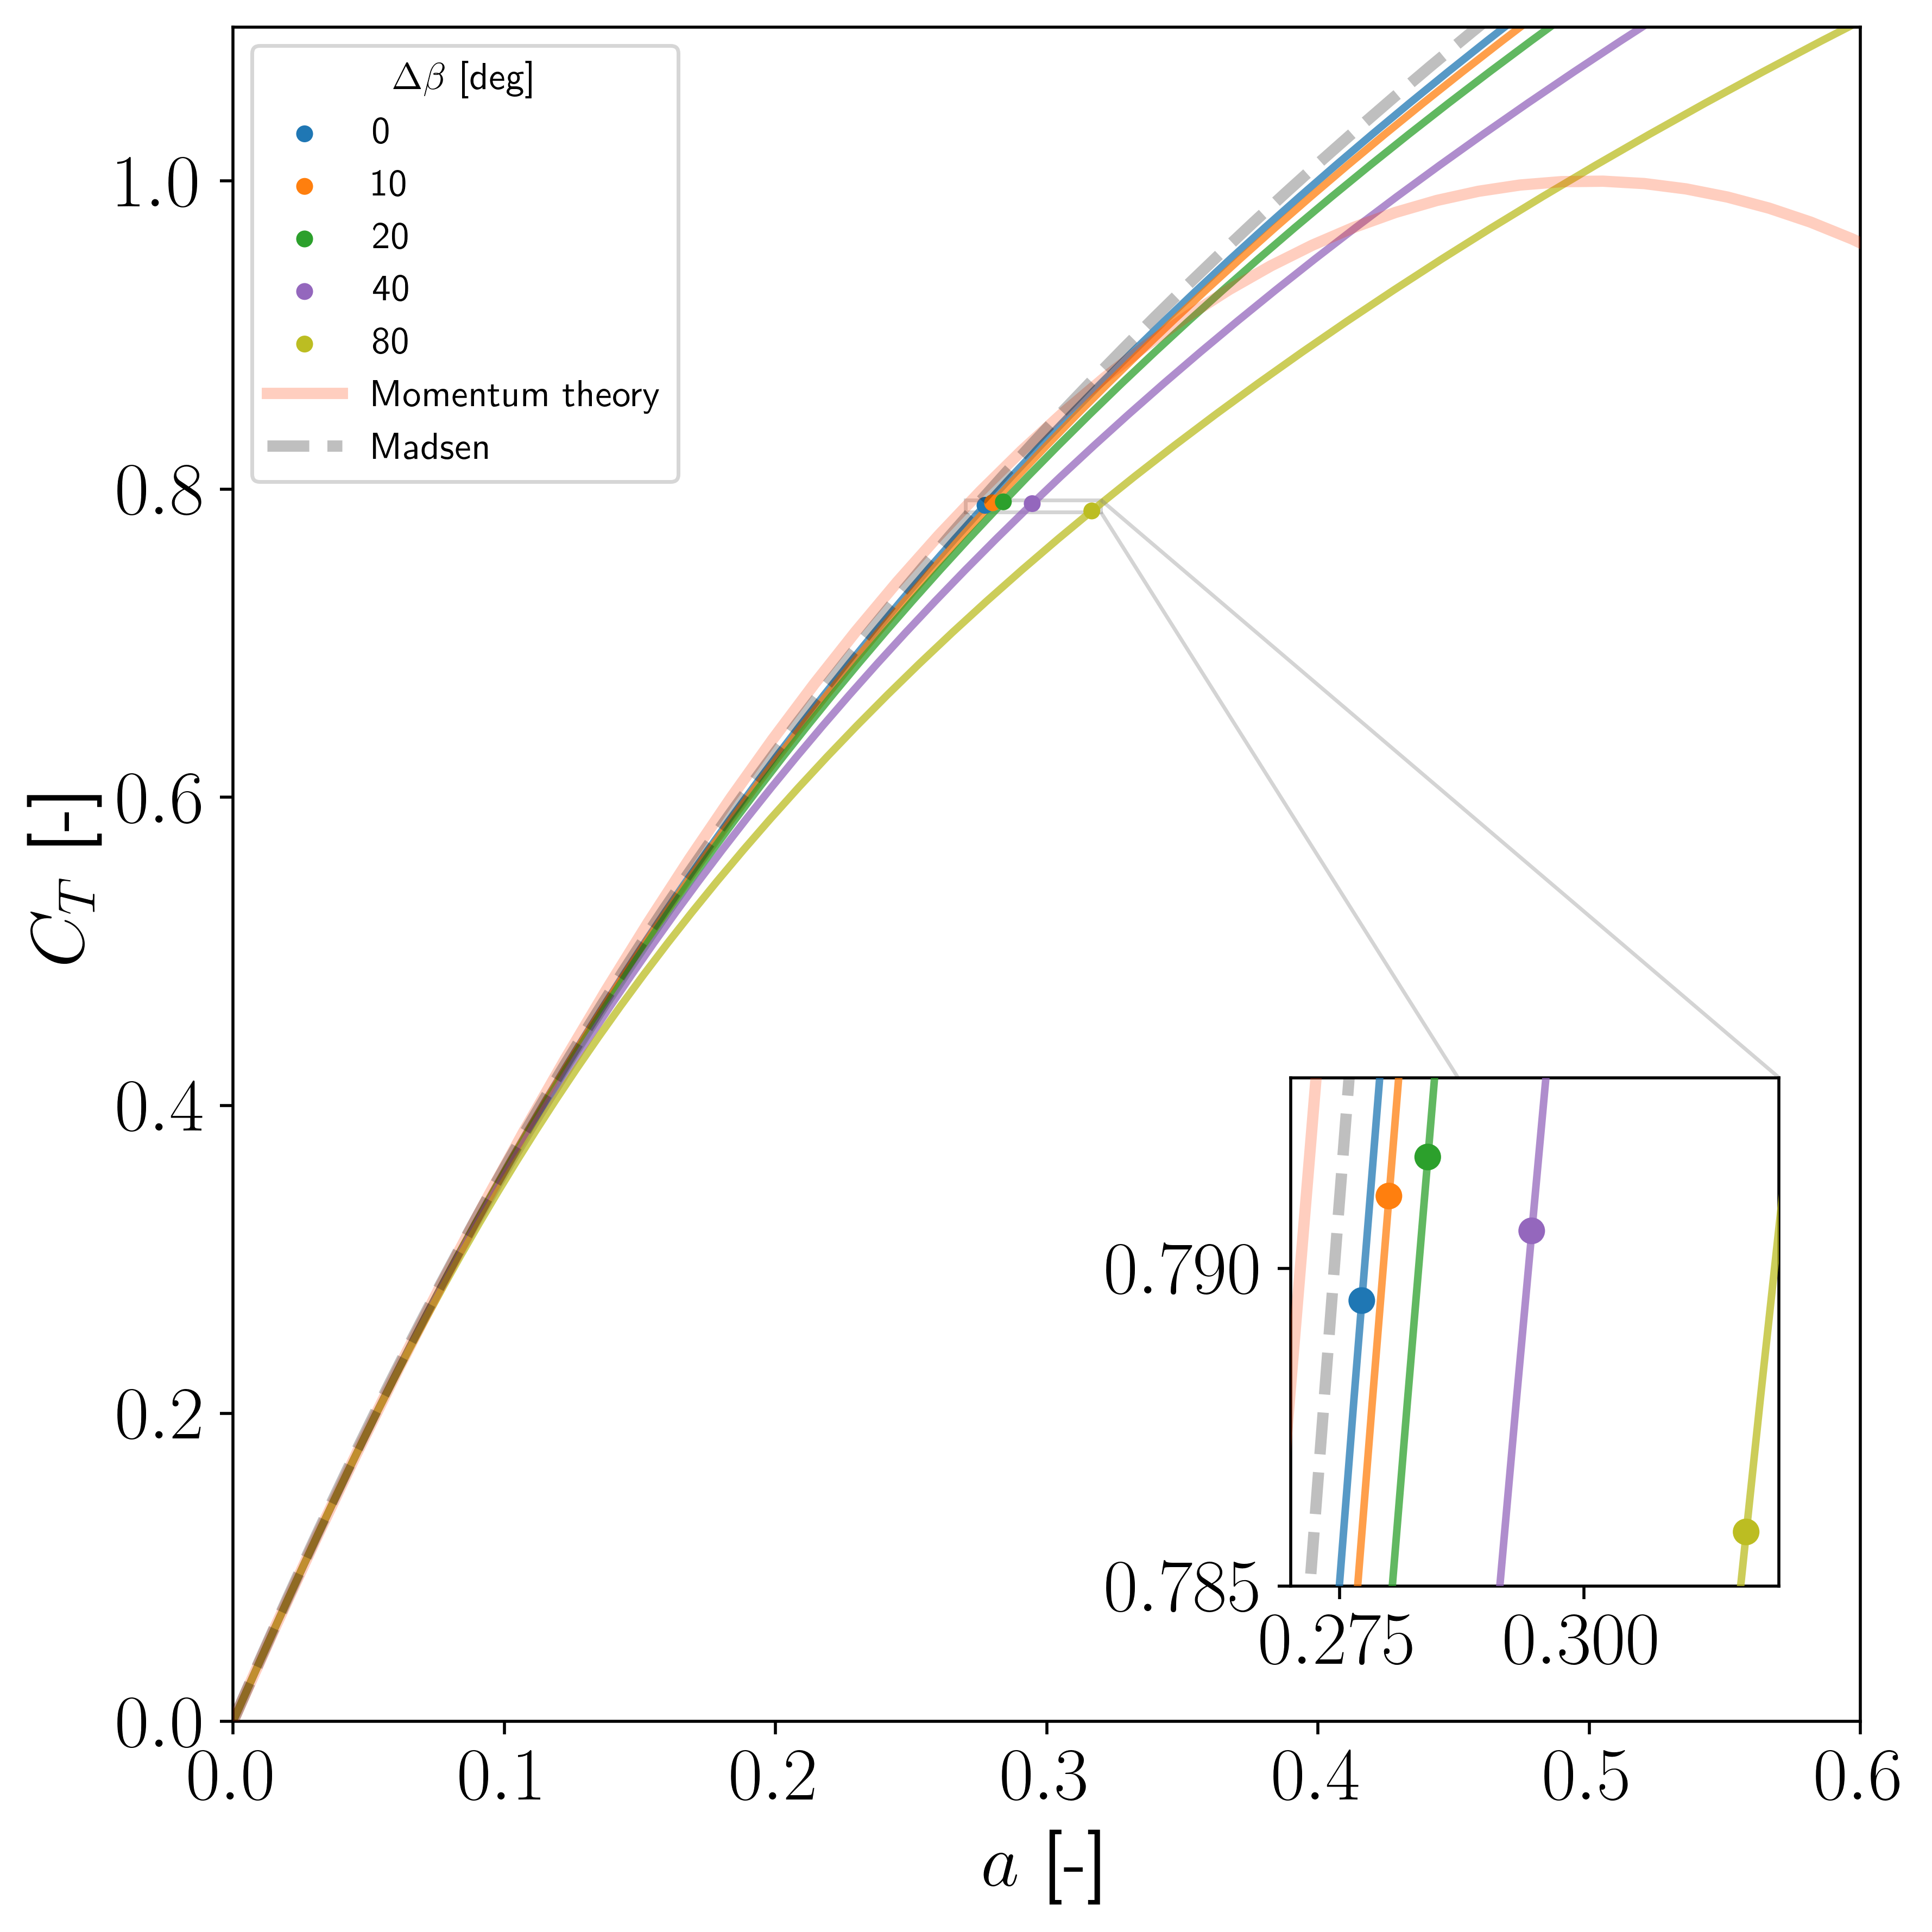

In [19]:
colors = sns.color_palette("tab10", 9)
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
# ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=4,alpha=0.25, label='Momentum theory')

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
# ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=5,alpha=0.25,label='Madsen')

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75)
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75)
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75)
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75)
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

# mesh = ax.scatter(wrf_ind[indices_n80], wrf_cot[indices_n80], marker='s', s=50, edgecolor='none',color=colors[8],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_n40], wrf_cot[indices_n40], marker='s', s=50, edgecolor='none',color=colors[4],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_n20], wrf_cot[indices_n20], marker='s', s=50, edgecolor='none',color=colors[2],zorder=3)
# mesh = ax.scatter(wrf_ind[indices_n10], wrf_cot[indices_n10], marker='s', s=50, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(wrf_ind[indices_00], wrf_cot[indices_00], s=20, edgecolor='none',color=colors[0],zorder=3,label='0')
mesh = ax.scatter(wrf_ind[indices_10], wrf_cot[indices_10], s=20, edgecolor='none',color=colors[1],zorder=3,label='10')
mesh = ax.scatter(wrf_ind[indices_20], wrf_cot[indices_20], s=20, edgecolor='none',color=colors[2],zorder=3,label='20')
mesh = ax.scatter(wrf_ind[indices_40], wrf_cot[indices_40], s=20, edgecolor='none',color=colors[4],zorder=3,label='40')
mesh = ax.scatter(wrf_ind[indices_80], wrf_cot[indices_80], s=20, edgecolor='none',color=colors[8],zorder=3,label='80')

ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=4,alpha=0.25, label='Momentum theory')
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=5,alpha=0.25,label='Madsen')

# mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',label='LES')

ax.legend(title='$\Delta \\beta$ [deg]', loc='upper left')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.65, 0.08, 0.3, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.27, 0.32], ylim=[0.785, 0.793] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8], linewidth=2, alpha=0.75,zorder=3)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

# Re-plot the scatter data
# inset_ax.scatter(wrf_ind[indices_n80], wrf_cot[indices_n80], marker='s', s=50, edgecolor='none',color=colors[8],zorder=3)
# inset_ax.scatter(wrf_ind[indices_n40], wrf_cot[indices_n40], marker='s', s=50, edgecolor='none',color=colors[4],zorder=3)
# inset_ax.scatter(wrf_ind[indices_n20], wrf_cot[indices_n20], marker='s', s=50, edgecolor='none',color=colors[2],zorder=3)
# inset_ax.scatter(wrf_ind[indices_n10], wrf_cot[indices_n10], marker='s', s=50, edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(wrf_ind[indices_00], wrf_cot[indices_00], s=50, edgecolor='none',color=colors[0],zorder=3)
inset_ax.scatter(wrf_ind[indices_10], wrf_cot[indices_10], s=50, edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(wrf_ind[indices_20], wrf_cot[indices_20], s=50, edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(wrf_ind[indices_40], wrf_cot[indices_40], s=50, edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(wrf_ind[indices_80], wrf_cot[indices_80], s=50, edgecolor='none',color=colors[8],zorder=3)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

plt.show()

In [52]:
allowed_values = [-80, -40, -20, -10, 0, 10, 20, 40, 80]
subset_indices = [i for i, (s, v) in enumerate(training) if (v in allowed_values and abs(s) == 0)]
wrf_ref_index  = [i for i, (s, v) in enumerate(training) if (v == 0 and s == 0)]

wrf_pow_ss = np.zeros_like(subset_indices, dtype='float')
wrf_thr_ss = np.zeros_like(subset_indices, dtype='float')
wrf_cot_ss = np.zeros_like(subset_indices, dtype='float')
wrf_ind_ss = np.zeros_like(subset_indices, dtype='float')
wrf_rel_ss = np.zeros_like(subset_indices, dtype='float')
wrf_vax_ss = np.zeros_like(subset_indices, dtype='float')
wrf_vtn_ss = np.zeros_like(subset_indices, dtype='float')

for i in range(len(np.zeros_like(subset_indices, dtype='float'))):
    wrf_pow_ss[i] = wrf_pow[subset_indices[i]]
    wrf_thr_ss[i] = wrf_thr[subset_indices[i]]
    wrf_cot_ss[i] = wrf_cot[subset_indices[i]]
    wrf_ind_ss[i] = wrf_ind[subset_indices[i]]
    wrf_rel_ss[i] = wrf_rel[subset_indices[i]]
    wrf_vax_ss[i] = wrf_vax[subset_indices[i]]
    wrf_vtn_ss[i] = wrf_vtn[subset_indices[i]]

In [54]:
wrf_ref_index

[59]

In [53]:
subset_indices

[51, 55, 57, 58, 59, 60, 61, 63, 67]

In [55]:
wrf_power_dev     = postproc.per_error(wrf_pow_ss, wrf_pow[wrf_ref_index])
wrf_thrust_dev    = postproc.per_error(wrf_thr_ss, wrf_thr[wrf_ref_index])
wrf_induction_dev = postproc.per_error(wrf_ind_ss, wrf_ind[wrf_ref_index])

# np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_dim_negV_NoS.npz", pow=wrf_pow_ss, thr=wrf_thr_ss, ind=wrf_ind_ss)

# np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_dev_negV_NoS.npz", pow=wrf_power_dev, thr=wrf_thrust_dev, ind=wrf_induction_dev)

In [56]:
replacements = {
    'sn030151': 'sn06',
    'sn020101': 'sn04',
    'sn010050': 'sn02',
    's000000' : 's00',
    's010050' : 's02',
    's020101' : 's04',
    's030151' : 's06',
    'vn402010' : 'vn80',
    'vn351759' : 'vn70',
    'vn301508' : 'vn60',
    'vn251256' : 'vn50',
    'vn201005' : 'vn40',
    'vn150754' : 'vn30',
    'vn100503' : 'vn20',
    'vn050251' : 'vn10',
    'v000000'  : 'v00',
    'v050251'  : 'v10',
    'v100503'  : 'v20',
    'v150754'  : 'v30',
    'v201005'  : 'v40',
    'v251256'  : 'v50',
    'v301508'  : 'v60',
    'v351759'  : 'v70',
    'v402010'  : 'v80'
}

In [57]:
sub_cases = [np.array(casenames)[subset_indices]]

formatted_cases = []
for name in sub_cases[0]:
    for old, new in replacements.items():
        if old in name:
            name = name.replace(old, new)
    formatted_cases.append(name)

# Result
new_names = np.array(formatted_cases)

In [58]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, ClassicalMomentum, Madsen_committee, ConstantInduction

In [59]:
rotor = IEA10MW()

In [60]:
u = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_u.npy')
v = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_v.npy')

In [61]:
rotor = IEA10MW()
veers = (np.array(training)[subset_indices][:, 1]/10).astype(int)

mit_ind = np.zeros_like(subset_indices, dtype='float')
mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_thr = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
mit_pow = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

mit_w   = np.zeros_like(subset_indices, dtype='float')
mit_cax = np.zeros_like(subset_indices, dtype='float')
mit_vax = np.zeros_like(subset_indices, dtype='float')
mit_vtn = np.zeros_like(subset_indices, dtype='float')

for count in range(len(subset_indices)):

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())
    # bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ClassicalMomentum(), tangential_induction_model=NoTangentialInduction())
    # bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_committee(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    tsr = wrf_tsr[subset_indices[count]] 

    rotor_U = (u[:,:,subset_indices[count]]**2 + v[:,:,subset_indices[count]]**2)**(1/2)

    rotor_dir = np.atan2(v[:,:,subset_indices[count]], u[:,:,subset_indices[count]])

    sol = bem(0, tsr, 0, U = rotor_U/Uhub[subset_indices[count]], wdir=rotor_dir)


    # sol = bem(0, tsr, 0, U = U_loc[:,:,subset_indices[count]], wdir=dir_loc[:,:,subset_indices[count]])
    # sol = bem(0, tsr, 0)

    rho = 1.225

    Nr = Nelm  # number of radial points
    Ntheta = Nsct  # number of azimuthal points

    # r = rOverR * R - rotor.hub_radius
    # r = rOverR * R
    # r = np.linspace(0,0.9999,26)

    r = np.linspace(0.0001, 0.99999, 26) * R

    theta = sol.geom.theta_mesh[0,:]
    R_grid, Theta_grid = np.meshgrid(r, theta, indexing='ij')  # shape (Nr, Ntheta)

    dr = (99.5 - 2.4)/26

    # r_wrf = rOverR * rotor.R
    # dr = r_wrf[1] - r_wrf[0]

    dtheta = 2 * np.pi / Ntheta
    dA = R_grid * dr * dtheta  # shape (Nr, Ntheta)

    # Vax = sol.Vax('sector')
    # Vtan = sol.Vtan('sector')

    # W = np.sqrt(Vax**2 + Vtan**2)

    # phi = np.arctan2(Vax, Vtan)

    # aoa = phi - rotor.twist(sol.geom.mu_mesh)
    # aoa = np.clip(aoa, -np.pi / 2, np.pi / 2)

    # Cl, Cd = rotor.clcd(sol.geom.mu_mesh, aoa)

    # Ctan = Cl * np.sin(phi) - Cd * np.cos(phi)
    # Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # sigma = rotor.solidity(sol.geom.mu_mesh)

    chord = np.array([4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734])

    # chord = rotor.chord_func(sol.geom.mu)

    Vrel = np.sqrt((sol.Vax('sector'))**2 + sol.Vtan('sector')**2) * Uhub[count]
    L = 1/2 * rho * chord * (sol.Cl('sector') * Vrel**2).T
    D = 1/2 * rho * chord * (sol.Cd('sector') * Vrel**2).T

    # L = wrf_L[:,:,count].T
    # D = wrf_D[:,:,count].T

    # phi = wrf_phi[:,:,count]

    FT = L.T * np.sin(sol.phi('sector')) - D.T * np.cos(sol.phi('sector'))
    FN = L.T * np.cos(sol.phi('sector')) + D.T * np.sin(sol.phi('sector'))

    # FT = L.T * np.sin(phi) - D.T * np.cos(phi)
    # FN = L.T * np.cos(phi) + D.T * np.sin(phi)

    sigma = 3/Nsct

    # sigma = (3 * chord / (2 * np.pi * r))[:, np.newaxis] * np.ones((26, 158)) 

    T_total = np.sum(FN * dr * sigma)/1e3

    P_total = np.sum(FT.T * r * dr * sigma * wrf_omg[count] * 2 * np.pi / 60)/1e6

    # integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Cn('sector')).T * r * dr * dtheta
    # T_total = np.sum(integrand)

    # integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Ctan('sector')).T * r**2 * dr * dtheta
    # P_total = np.sum(integrand) * ((tsr) * Uhub[count] / rotor.R) 

    mit_cot[count] = sol.Ct()
    mit_thr[count] = T_total
    mit_pow[count] = P_total
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count]   = sol.niter
    mit_w[count]   = sol.W()
    mit_cax[count] = sol.Cn()
    mit_vax[count] = sol.Vax()
    mit_vtn[count] = sol.Vtan()
    
iters

array([10., 10., 10., 10., 10., 10., 10., 10., 10.])

In [62]:
mit_thr

array([673.71404553, 689.82038604, 697.95935132, 701.38158412,
       704.11749466, 705.99100067, 707.0196044 , 706.97495428,
       703.96259123])

In [63]:
wrf_thr[subset_indices]/1e3

array([685.0263125, 701.244625 , 709.1465625, 712.368    , 714.8298125,
       716.3841875, 717.01475  , 716.125    , 711.7068125])

In [66]:
# mit_power_dev     = postproc.per_error(mit_pow, mit_pow[4])
# mit_thrust_dev    = postproc.per_error(mit_thr, mit_thr[4])


mit_power_dev     = postproc.per_error(mit_cop, mit_cop[4])
mit_thrust_dev    = postproc.per_error(mit_cot, mit_cot[4])
mit_induction_dev = postproc.per_error(mit_ind, mit_ind[4])

# mit_power_dev     = mit_power_dev * 0
# mit_thrust_dev    = mit_power_dev * 0
# mit_induction_dev = mit_power_dev * 0

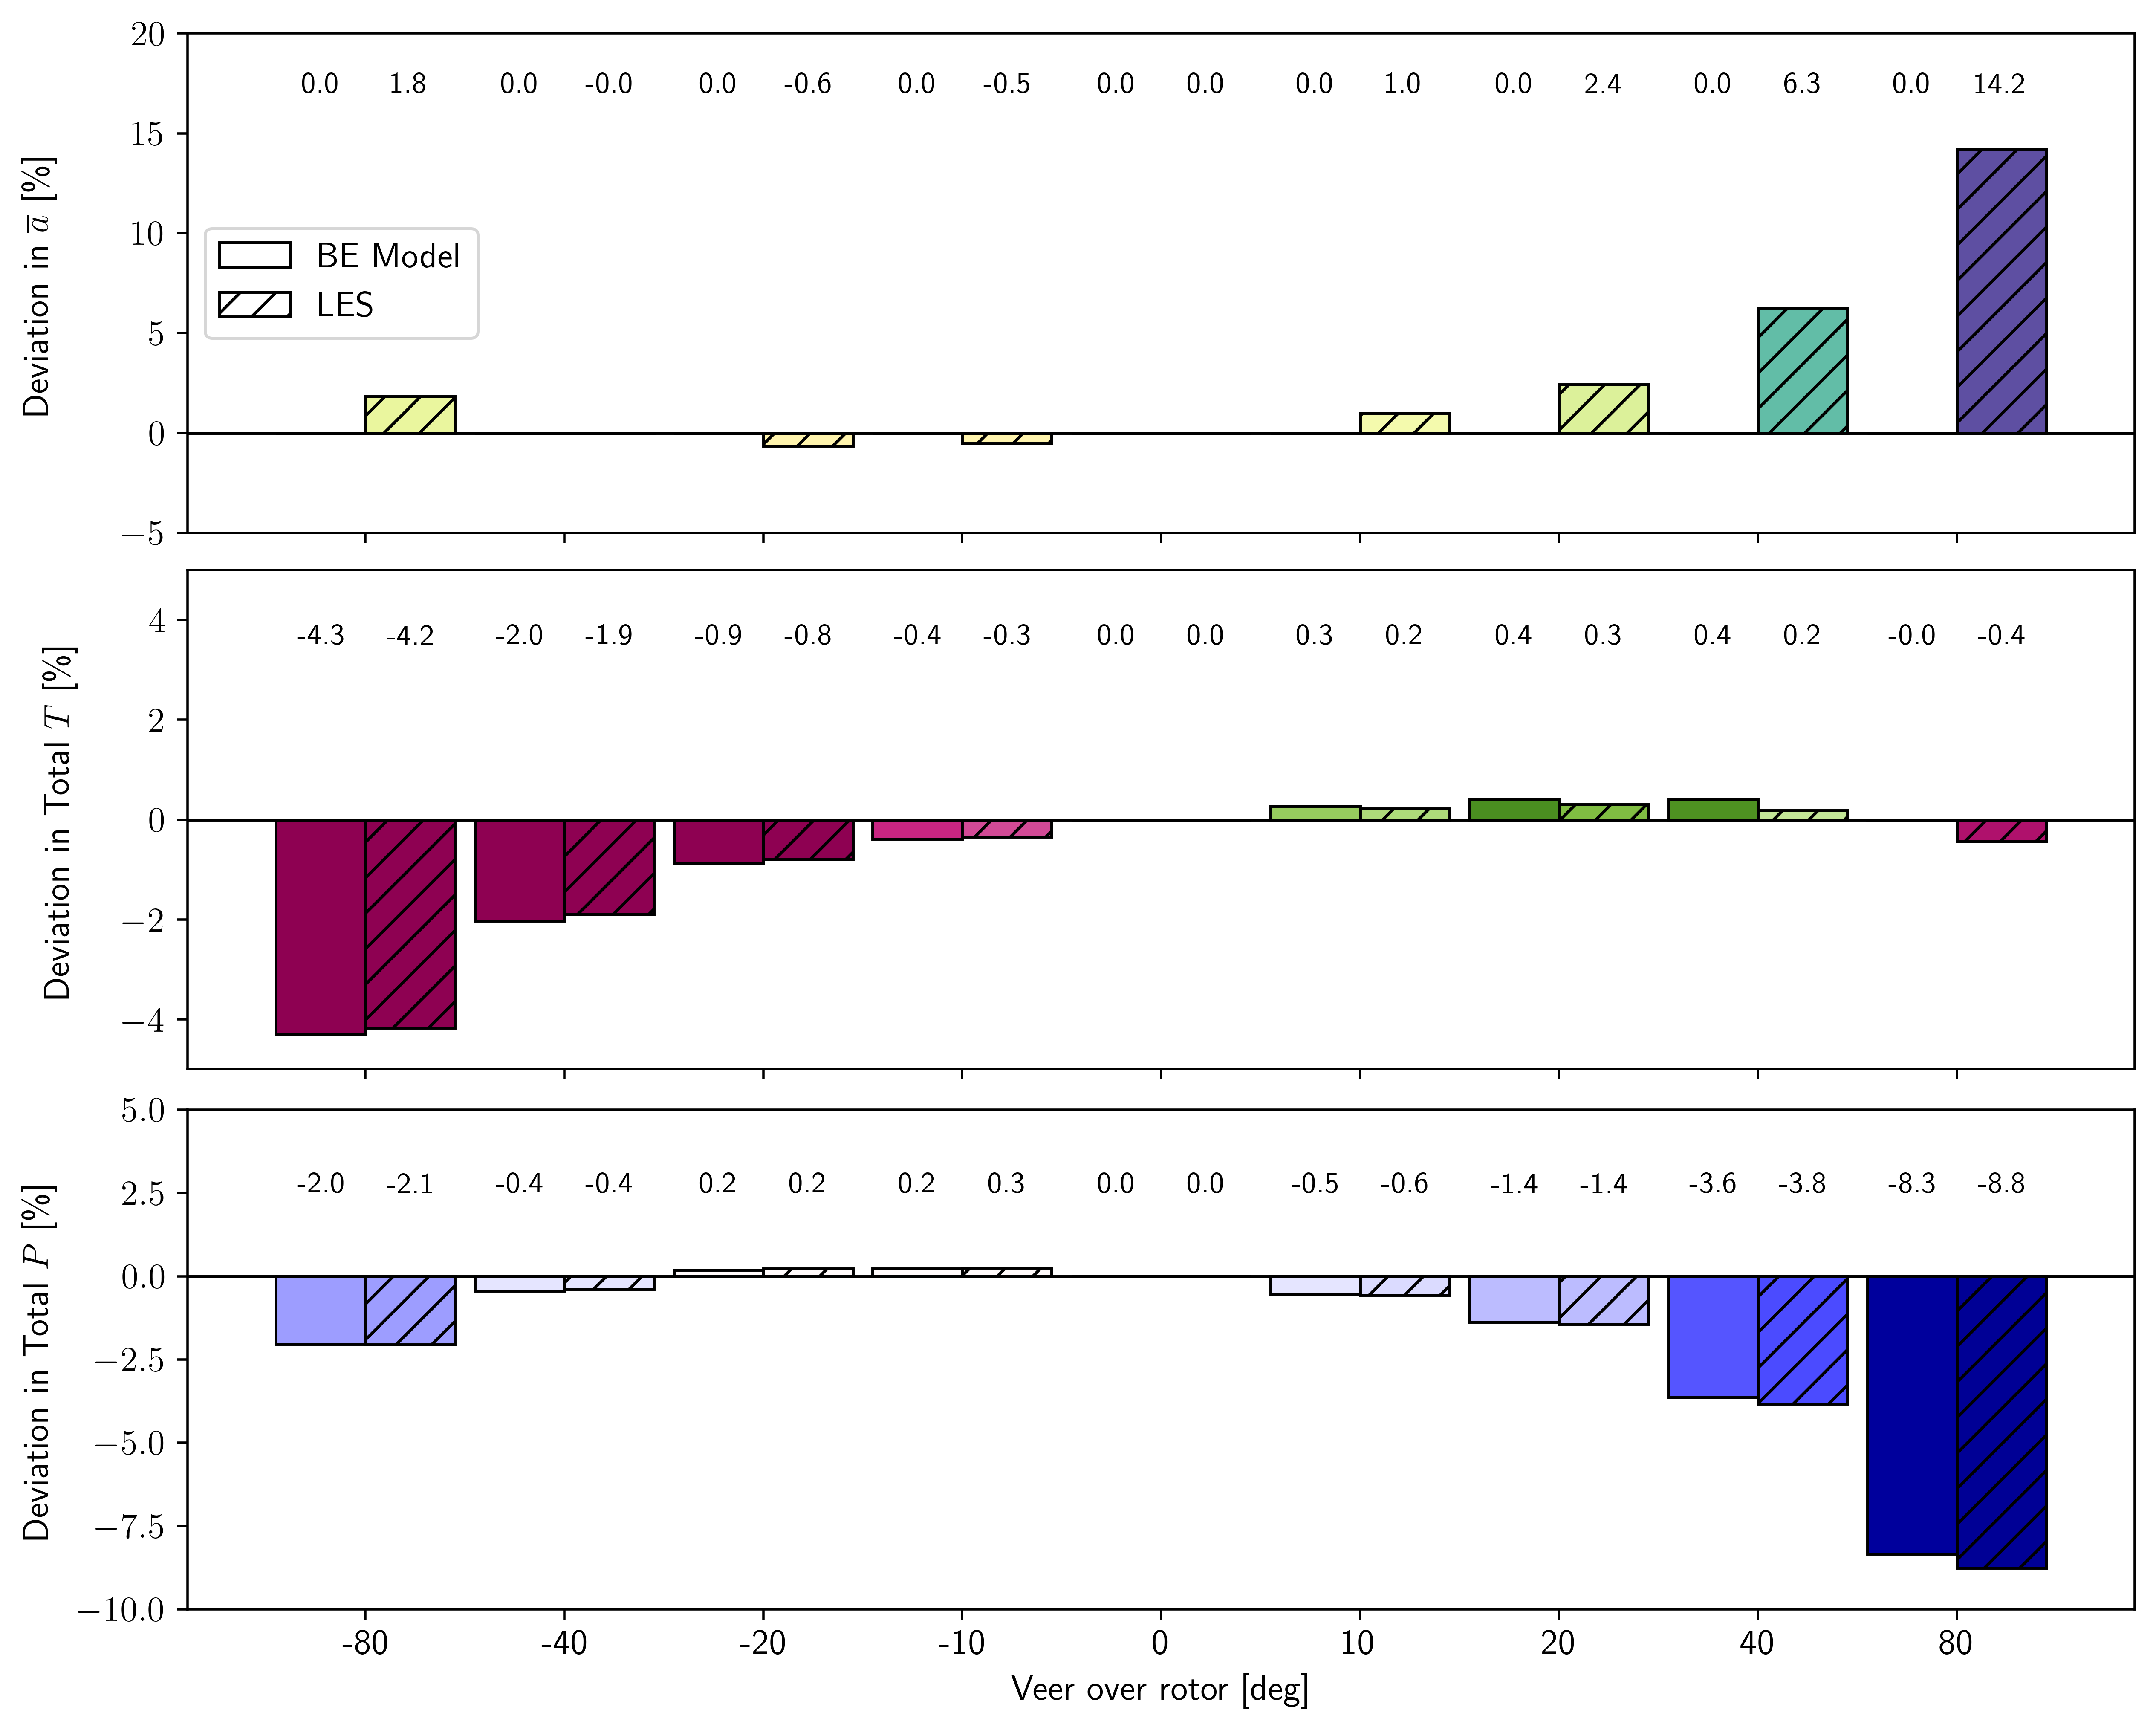

In [67]:
# Relative

width = 0.45
alpha = 1.0
fontsize = 12
labelsize = 10

n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-11, vmax=11)  # Normalize power to [0, 1]
wrf_pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in wrf_power_dev]  # Map power to discrete colors
mit_pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in mit_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)  # Normalize power to [0, 1]
wrf_thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in wrf_thrust_dev]  # Map power to discrete colors
mit_thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in mit_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-10, vmax=10)  # Normalize power to [0, 1]
wrf_ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in wrf_induction_dev]  # Map power to discrete colors
mit_ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in mit_induction_dev]  # Map power to discrete colors

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Induction
    ax[0].bar(ind[count] - width/2, mit_induction_dev[count], width,
              color=mit_ind_cmap[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_induction_dev[count], width,
              color=wrf_ind_cmap[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 17,
               f'{mit_induction_dev[count]:0.1f}%', ha='center', fontsize=labelsize)
    
    ax[0].text(ind[count] + width/2, 17,
               f'{wrf_induction_dev[count]:0.1f}%', ha='center', fontsize=labelsize)
    
    ax[0].set_ylabel(r'Deviation in $\overline{a}$ [\%]', fontsize=fontsize, labelpad=22)
    ax[0].set_ylim([-5,20])

    # --- Thrust
    ax[1].bar(ind[count] - width/2, mit_thrust_dev[count], width,
              color=mit_thr_cmap[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thrust_dev[count], width,
              color=wrf_thr_cmap[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 3.5,
               f'{mit_thrust_dev[count]:0.1f}%', ha='center', fontsize=labelsize)
    
    ax[1].text(ind[count] + width/2, 3.5,
               f'{wrf_thrust_dev[count]:0.1f}%', ha='center', fontsize=labelsize)
    
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize, labelpad=15)
    ax[1].set_ylim([-5,5])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_power_dev[count], width,
              color=mit_pow_cmap[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_power_dev[count], width,
              color=wrf_pow_cmap[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, 2.5,
               f'{mit_power_dev[count]:0.1f}%', ha='center', fontsize=labelsize)
    
    ax[2].text(ind[count] + width/2, 2.5,
               f'{wrf_power_dev[count]:0.1f}%', ha='center', fontsize=labelsize)
    
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize, labelpad=7)
    ax[2].set_ylim([-10,5])

# Final formatting
ax[2].set_xticks(ind)

xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax[2].set_xticklabels(xaxislabels, fontsize=fontsize)
ax[2].set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

for axs in ax.flat:
    axs.tick_params(axis='y', labelsize=fontsize)

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='BE Model'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

# Add legend to the top plot
ax[0].legend(handles=legend_handles, fontsize=fontsize, loc='center left')

plt.show()

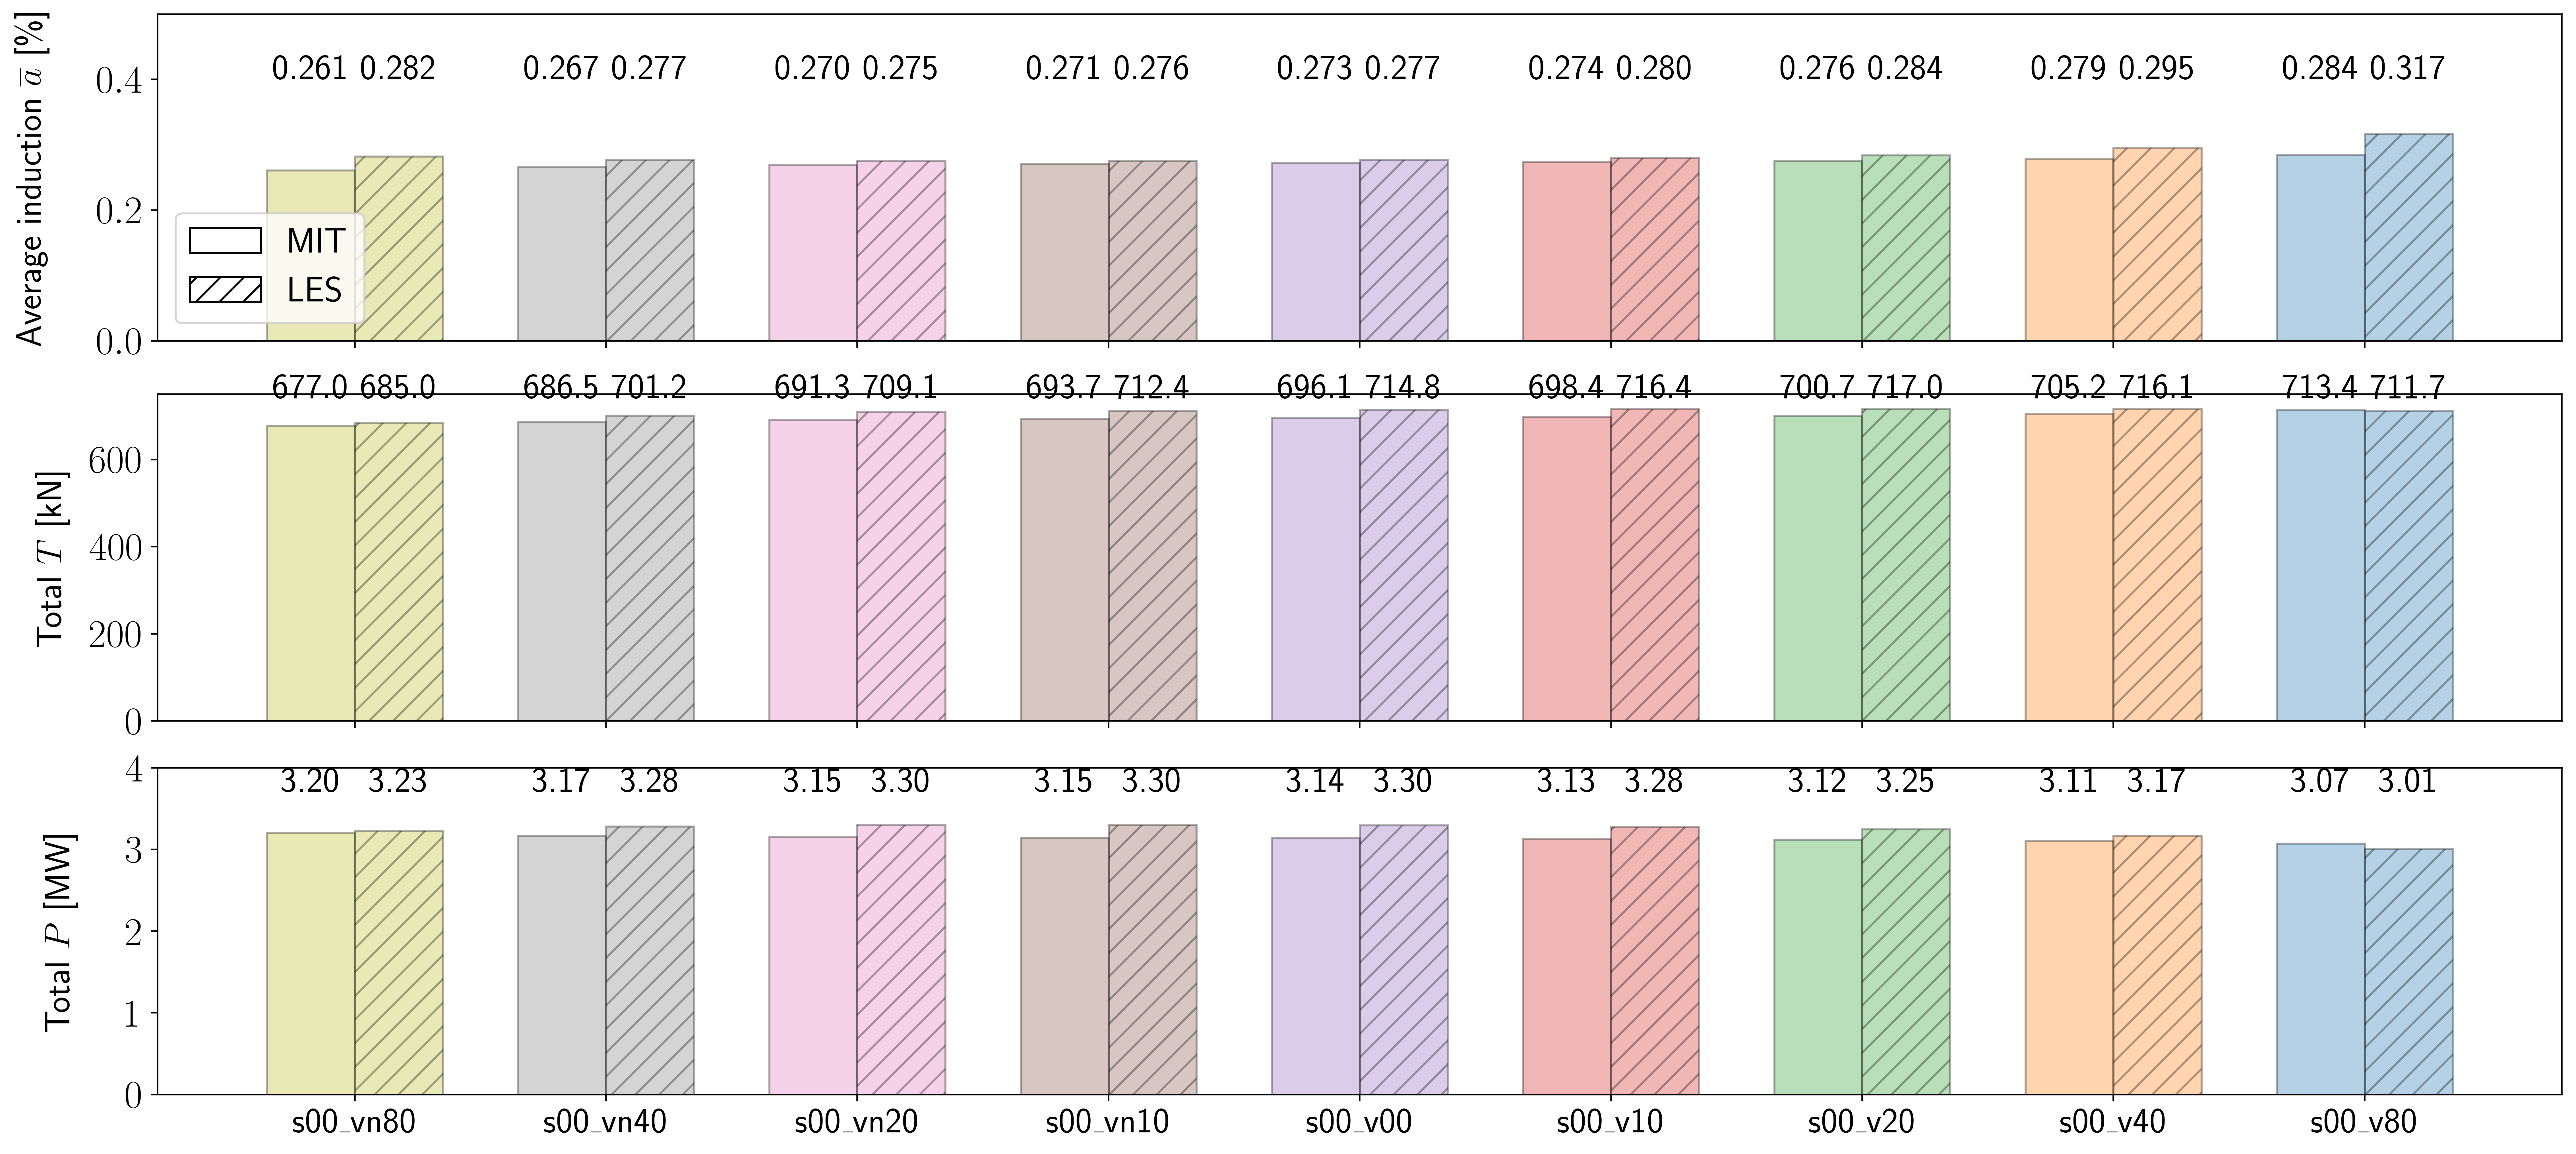

In [118]:
# Dimensional
colors = sns.color_palette("tab10", 9)

width = 0.35
alpha = 1/3
fontsize = 18

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Induction

    ax[0].bar(ind[count] - width/2, mit_ind[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_ind_ss[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 0.4,
               f'{mit_ind[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].text(ind[count] + width/2, 0.4,
               f'{wrf_ind_ss[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].set_ylabel(r'Average induction $\overline{a}$ [\%]', fontsize=fontsize, labelpad=24)
    ax[0].set_ylim([0, 0.5])

    # --- Thrust

    ax[1].bar(ind[count] - width/2, mit_thr[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thr_ss[count]/1e3, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 740,
               f'{mit_thr[count]:0.1f}%', ha='center', fontsize=fontsize)
    
    ax[1].text(ind[count] + width/2, 740,
               f'{wrf_thr_ss[count]/1e3:0.1f}%', ha='center', fontsize=fontsize)
    
    ax[1].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize, labelpad=10)
    ax[1].set_ylim([650, 750])
    ax[1].set_ylim([0, 750])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_pow[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_pow_ss[count]/1e6, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, 3.7,
               f'{mit_pow[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].text(ind[count] + width/2, 3.7,
               f'{wrf_pow_ss[count]/1e6:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize, labelpad=24)
    ax[2].set_ylim([2, 4])
    ax[2].set_ylim([0, 4])

# Final formatting
ax[2].set_xticks(ind)
ax[2].set_xticklabels(new_names, fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='MIT'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

# Add legend to the top plot
ax[0].legend(handles=legend_handles, fontsize=fontsize, loc='lower left')

plt.show()


Text(0.5, 0, '$a$ [-]')

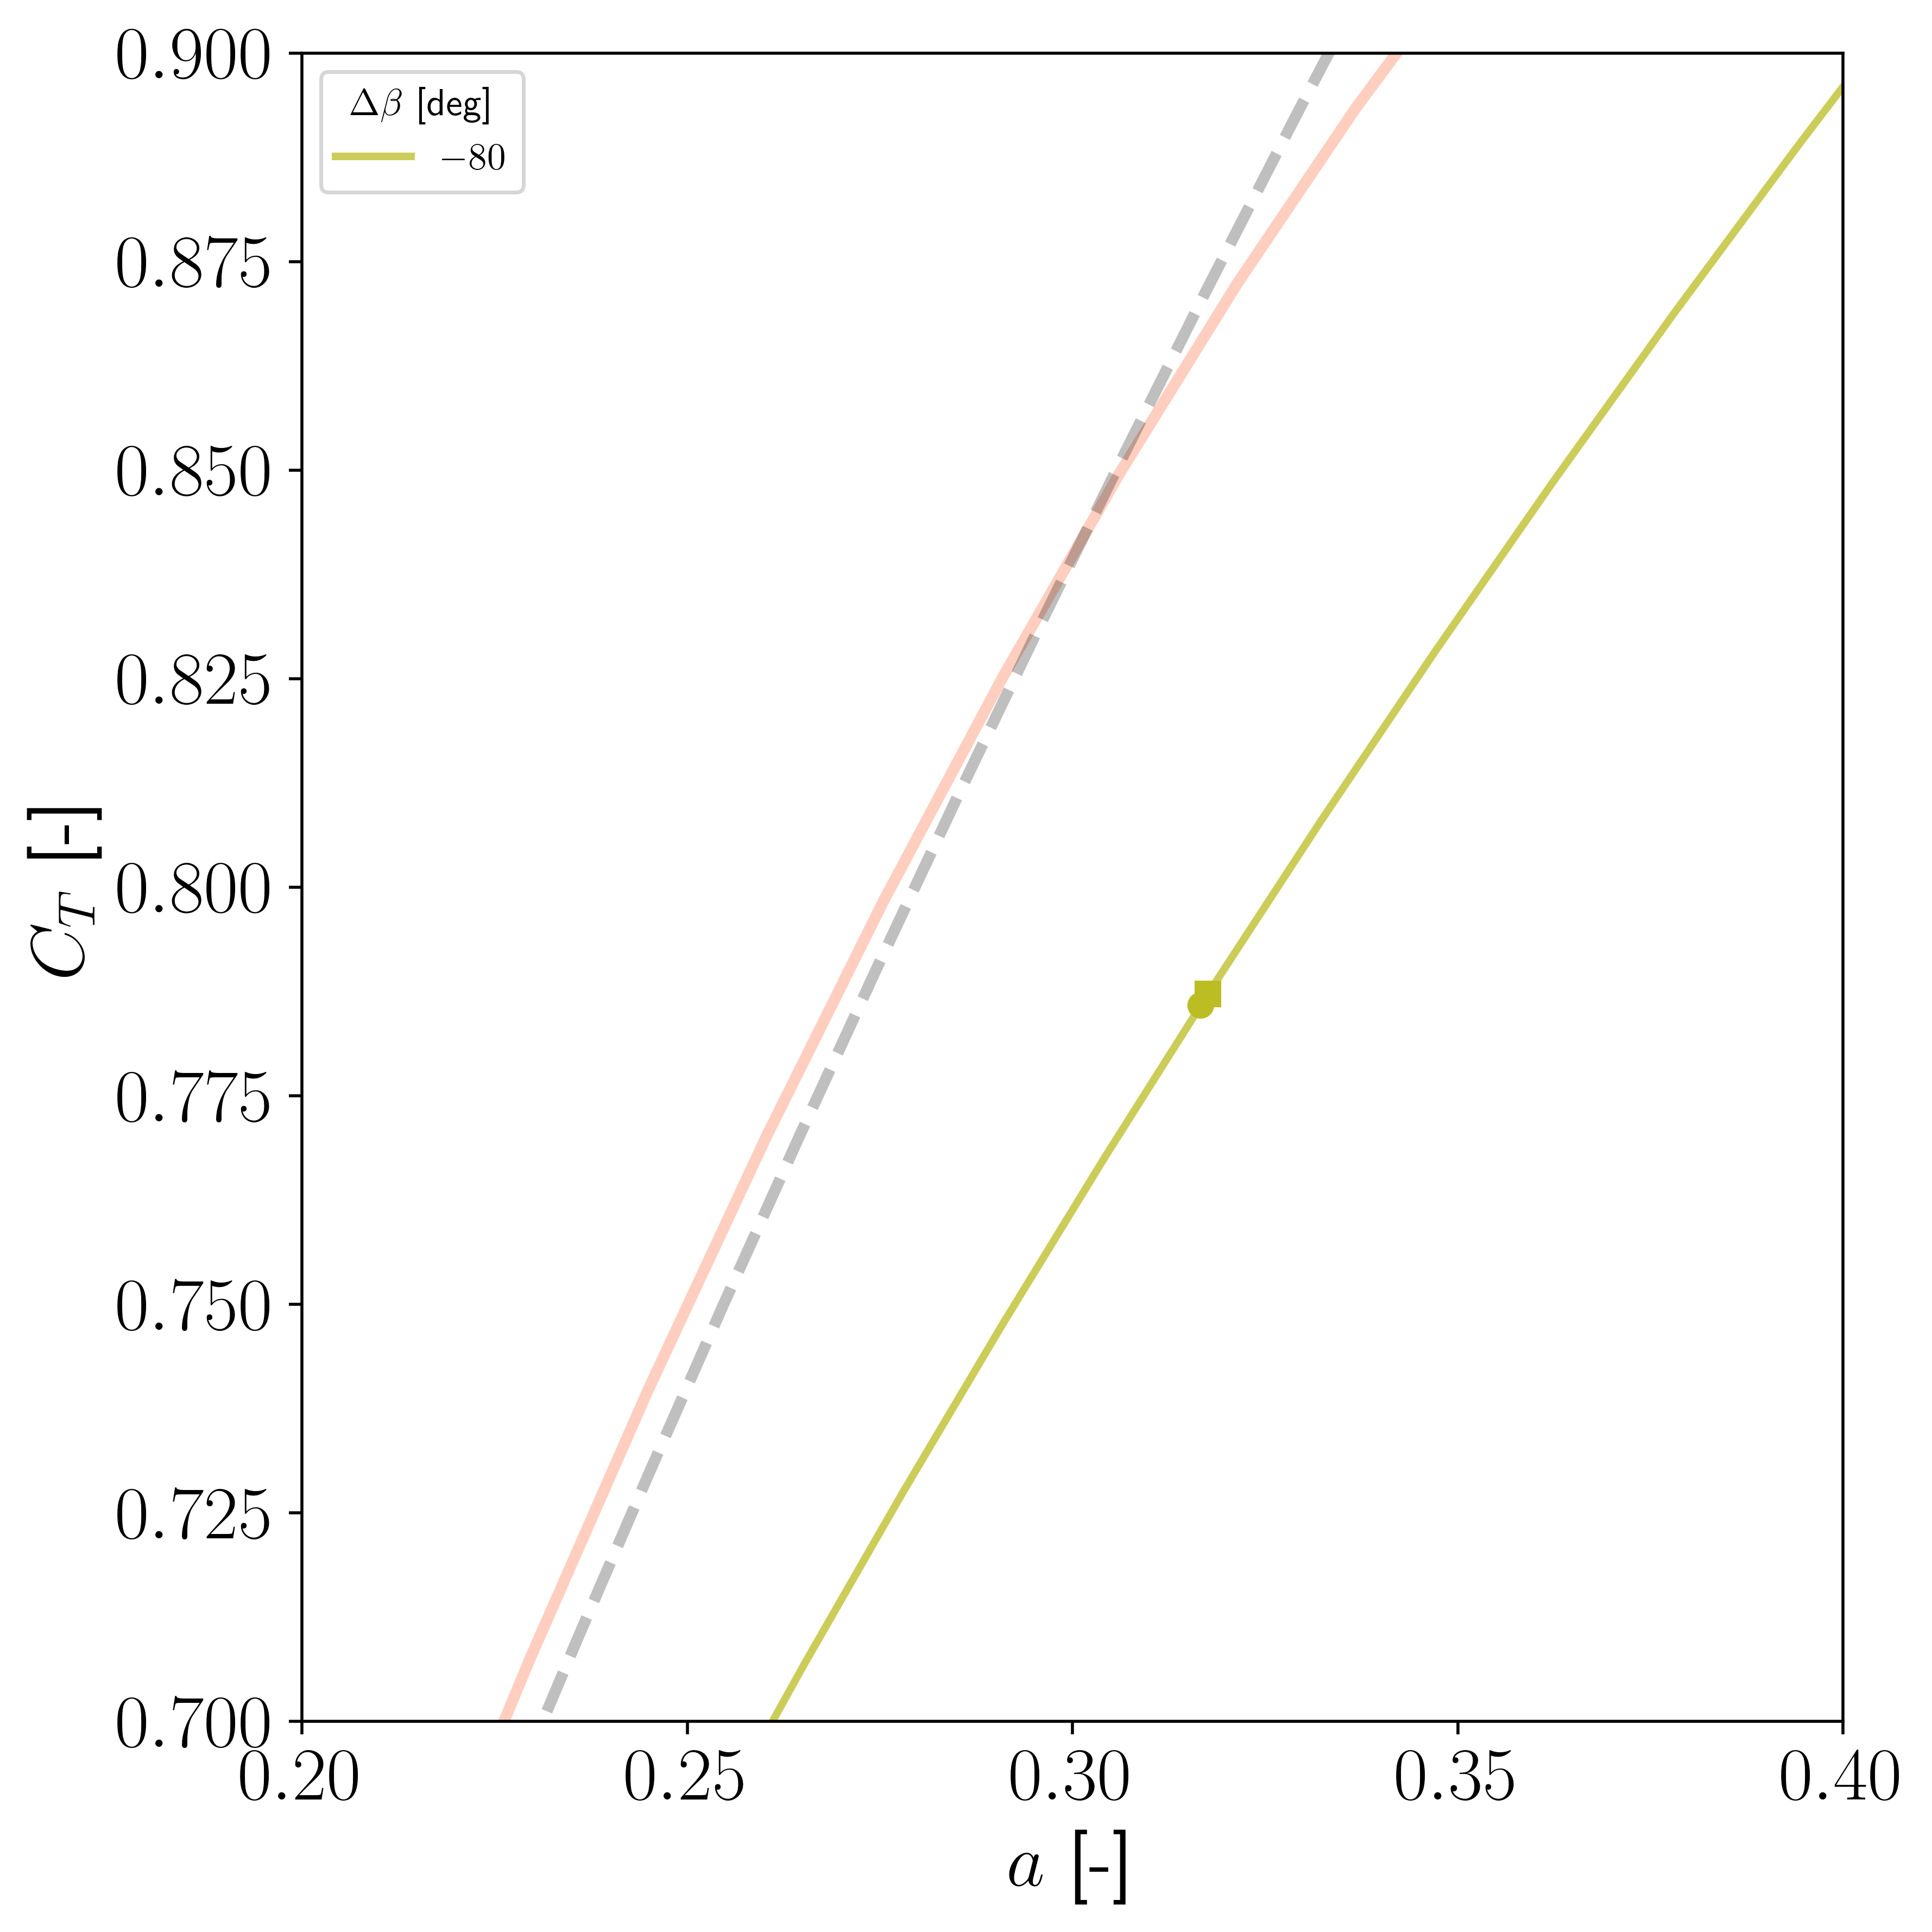

In [58]:
colors = sns.color_palette("tab10", 9)

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)
colors = sns.color_palette("tab10", 9)
a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

# ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
# ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$-10$')
# ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$-20$')
# ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$-40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$-80$')

# t=2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(sol.Ct('sector'), theta, axis=-1) * np.linspace(0,1,26), np.linspace(0,1,26))
# axind=2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(sol.a('sector'), theta, axis=-1) * np.linspace(0,1,26), np.linspace(0,1,26))

# ax.scatter(axind, t, s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)

# ax.scatter(mit_ind, mit_cot, s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
# mesh = ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
# mesh = ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)
# mesh = ax.scatter(mit_ind[6], mit_cot[6], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
# mesh = ax.scatter(mit_ind[7], mit_cot[7], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[8], mit_cot[8], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)

# mesh = ax.scatter(wrf_ind[0], wrf_cot[0], s=50, edgecolor='none',color=colors[8],zorder=3)

mesh = ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=50, edgecolor='none',color=colors[8],zorder=3)
# mesh = ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=50, edgecolor='none',color=colors[4],zorder=3)
# mesh = ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=50, edgecolor='none',color=colors[2],zorder=3)
# mesh = ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=50, edgecolor='none',color=colors[1],zorder=3)
# mesh = ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=50, edgecolor='none',color=colors[0],zorder=3)

# mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
# mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

# ax.set_xlim([0,0.6])
# ax.set_ylim([0,1.5])

ax.set_xlim([0.2,0.4])
ax.set_ylim([0.7,0.9])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

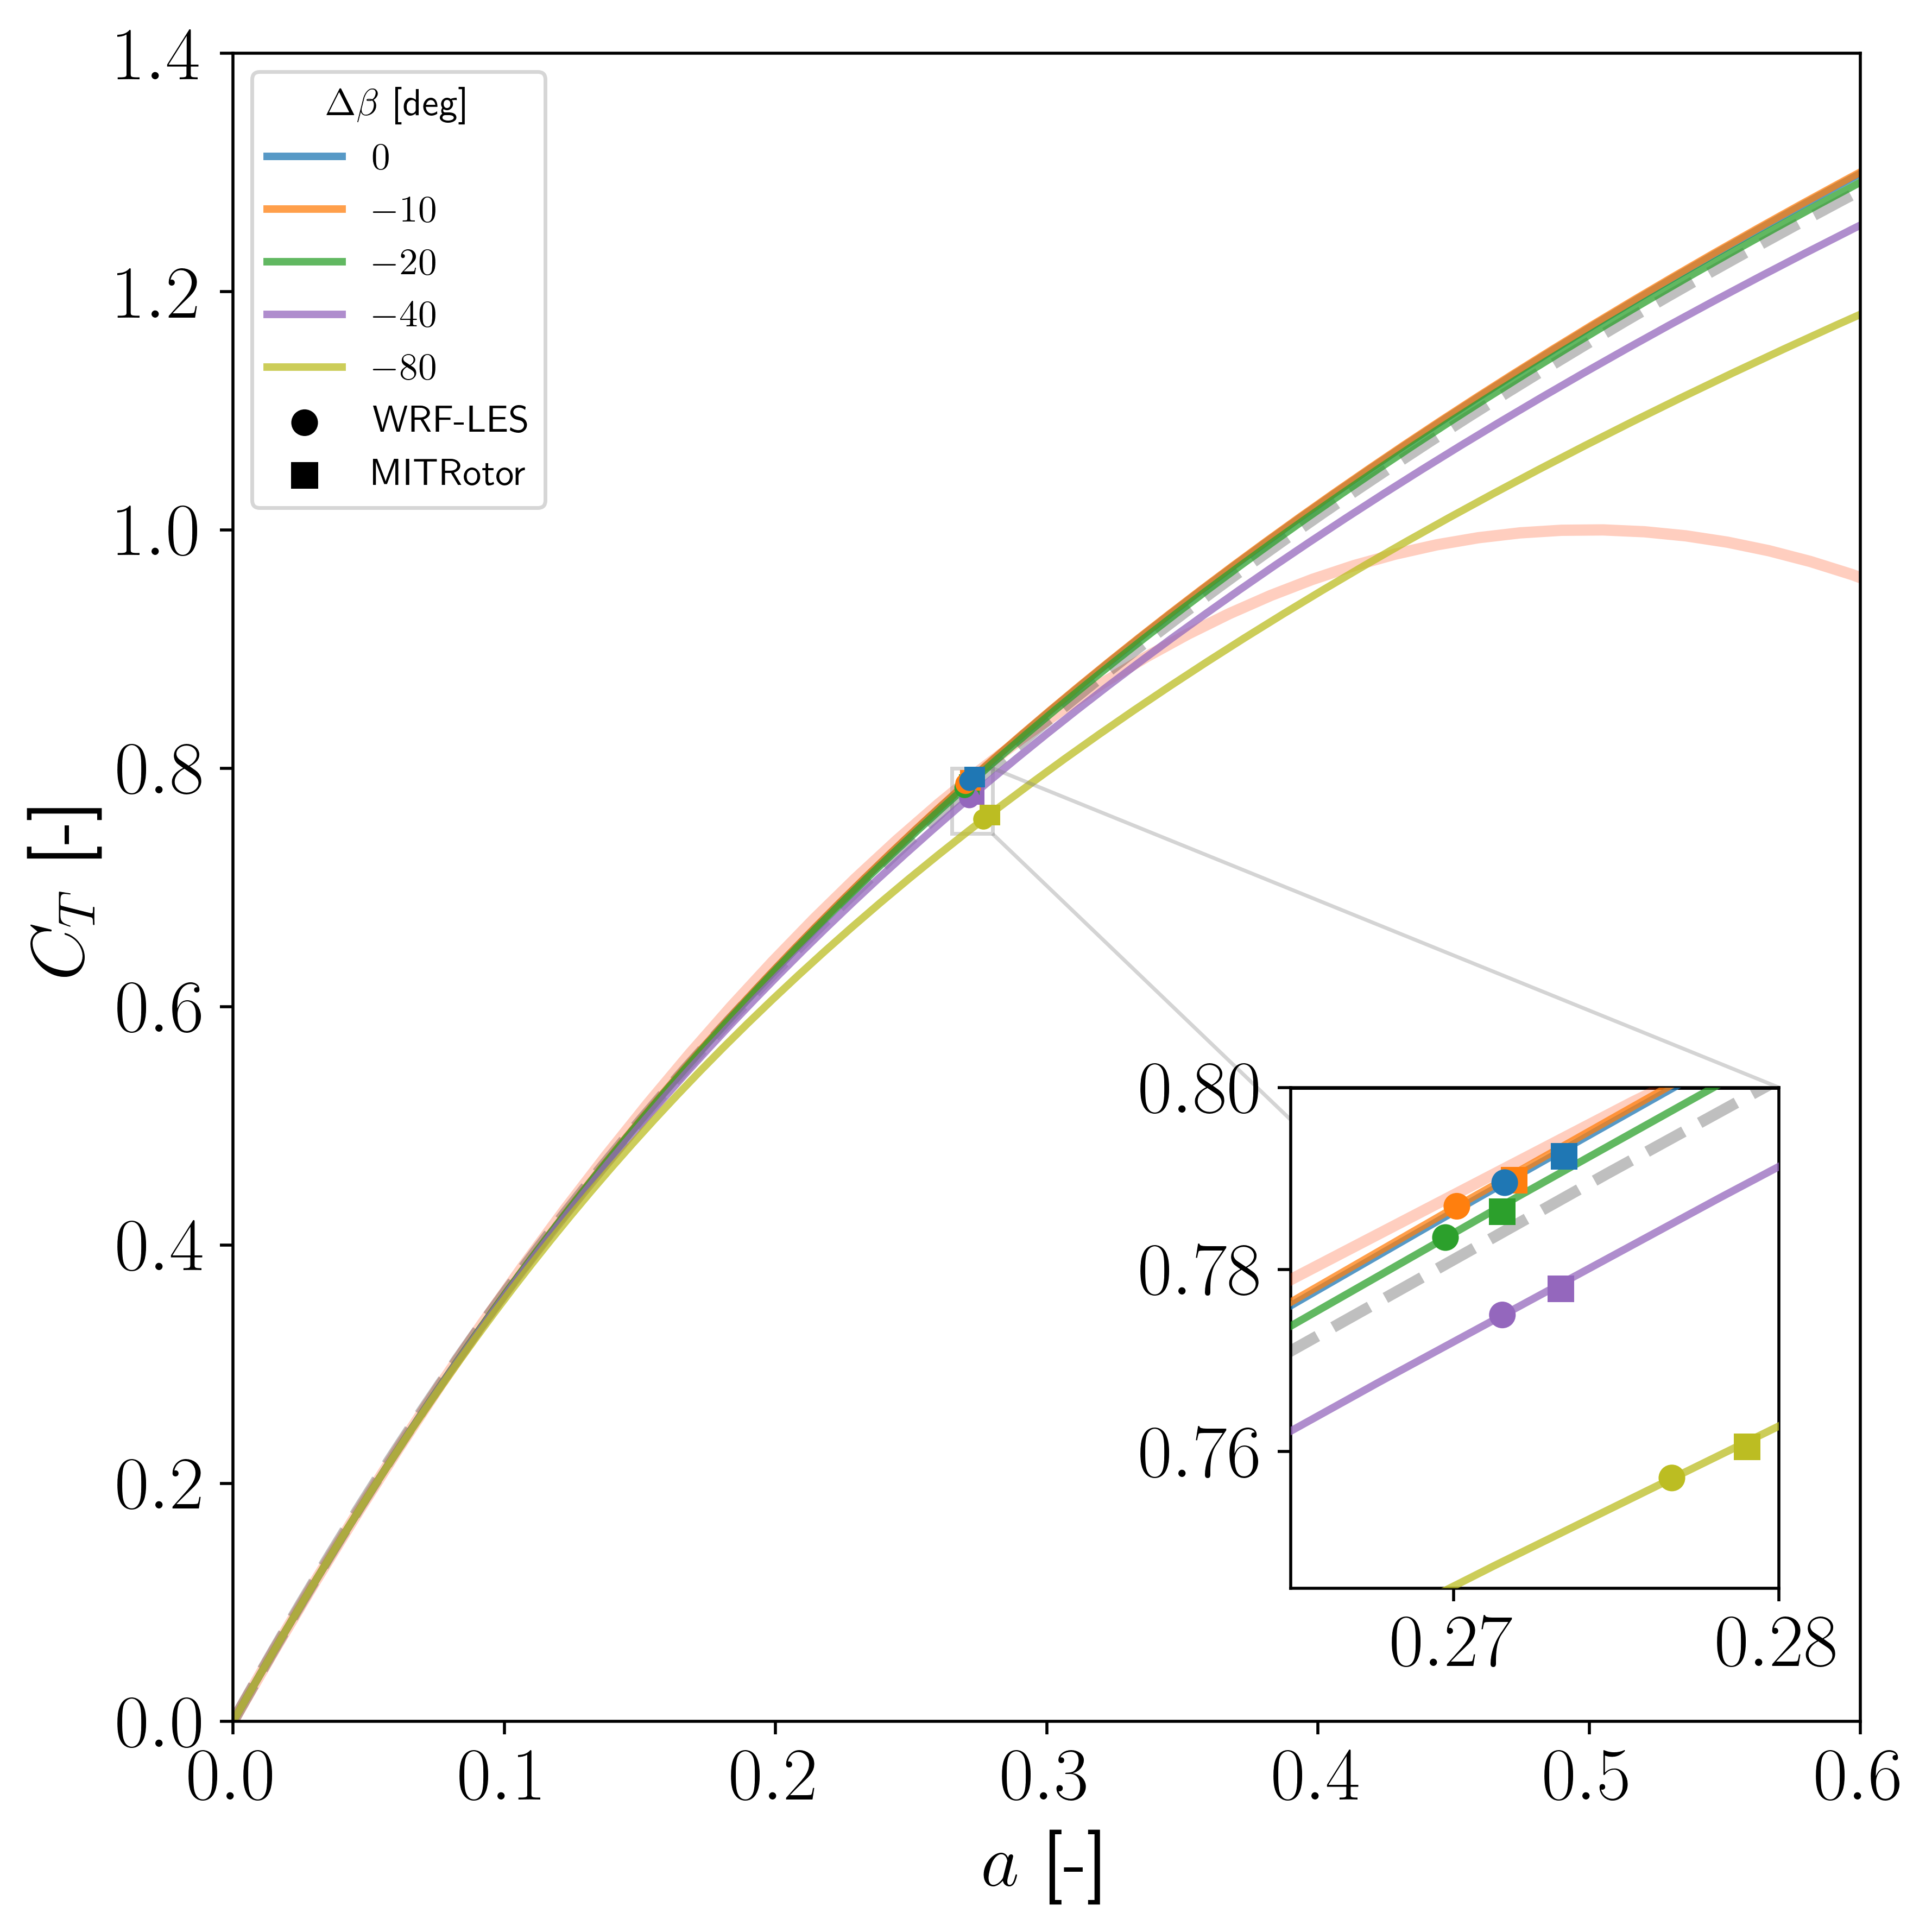

In [335]:
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$-10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$-20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$-40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$-80$')

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=30, marker='s', edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=30, marker='s', edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(mit_ind[6], mit_cot[6], s=30, marker='s', edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[7], mit_cot[7], s=30, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[8], mit_cot[8], s=30, marker='s', edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=30, edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=30, edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=30, edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=30, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=30, edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.65, 0.08, 0.3, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.265, 0.28], ylim=[0.745, 0.8] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=3,alpha=0.75)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

inset_ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
inset_ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(mit_ind[6], mit_cot[6], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(mit_ind[7], mit_cot[7], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(mit_ind[8], mit_cot[8], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

inset_ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=50, edgecolor='none',color=colors[8],zorder=3)
inset_ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=50, edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=50, edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=50, edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=50, edgecolor='none',color=colors[0],zorder=3)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.4])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

plt.show()

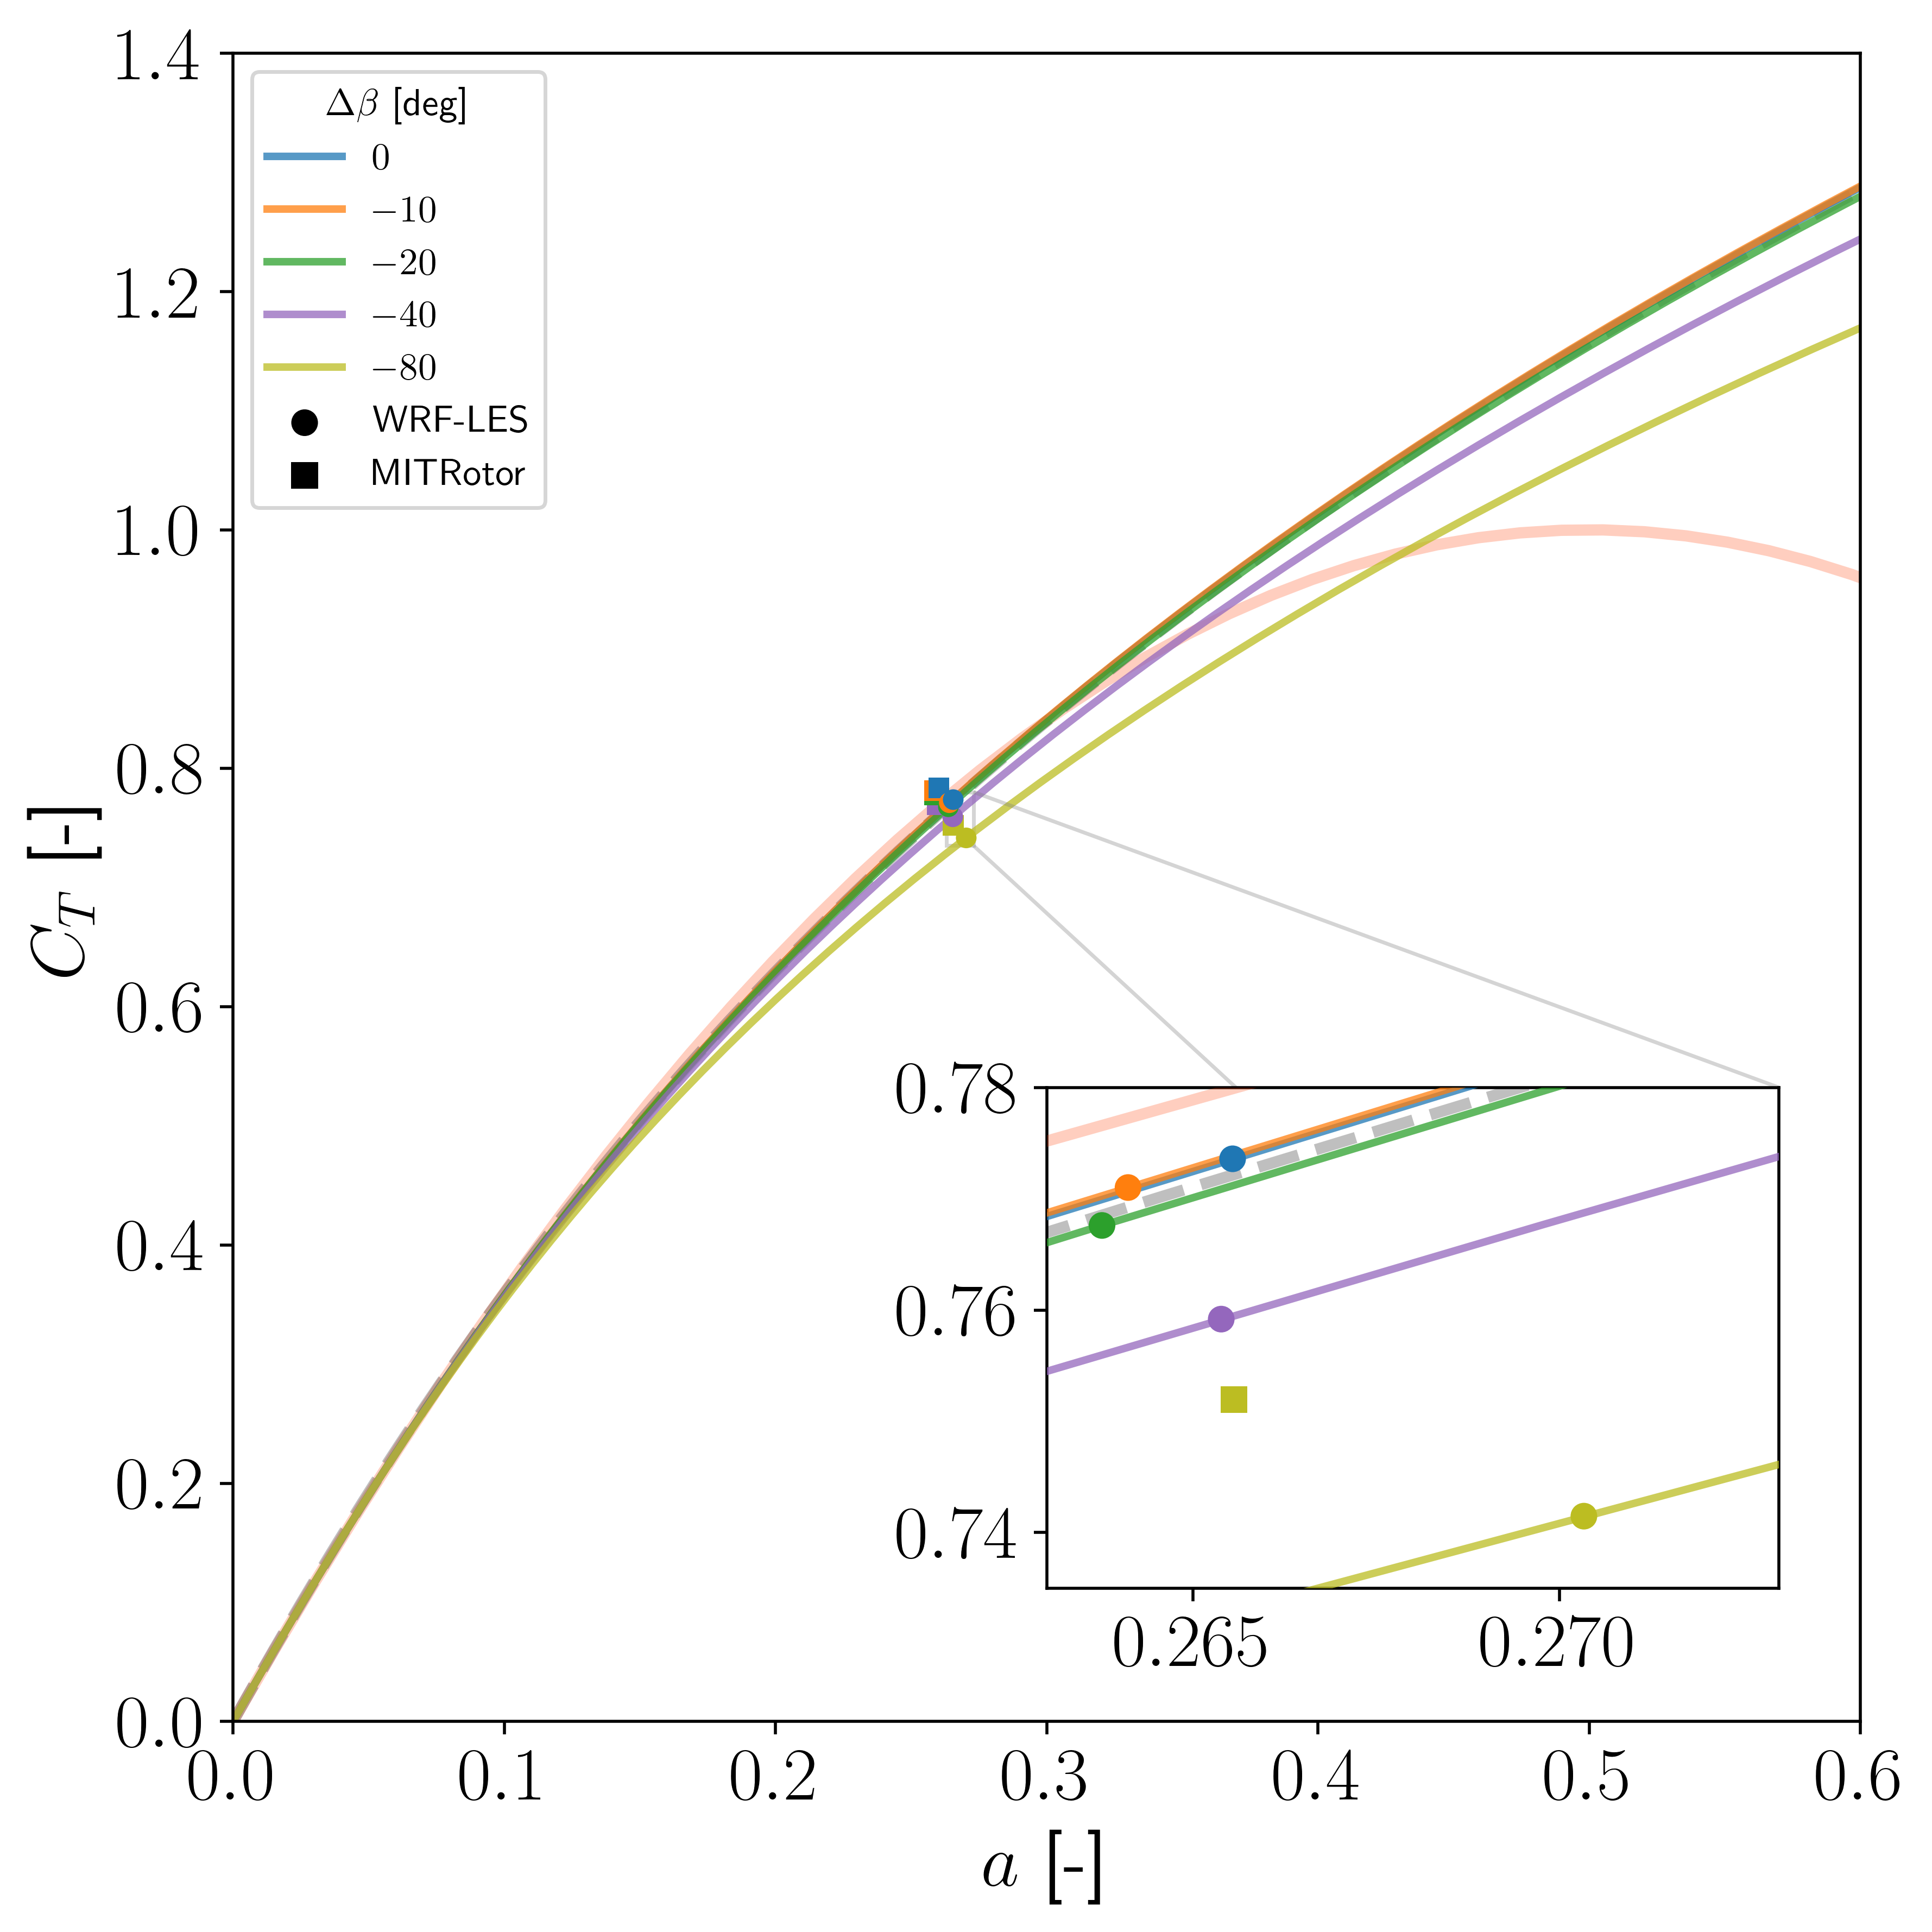

In [40]:
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$-10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$-20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$-40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$-80$')

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=30, marker='s', edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=30, marker='s', edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(mit_ind[6], mit_cot[6], s=30, marker='s', edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[7], mit_cot[7], s=30, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[8], mit_cot[8], s=30, marker='s', edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=30, edgecolor='none',color=colors[8],zorder=3)
mesh = ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=30, edgecolor='none',color=colors[4],zorder=3)
mesh = ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=30, edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=30, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=30, edgecolor='none',color=colors[0],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.263, 0.273], ylim=[0.735, 0.78] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=3,alpha=0.75)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=3,alpha=0.75)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

inset_ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
inset_ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(mit_ind[6], mit_cot[6], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(mit_ind[7], mit_cot[7], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(mit_ind[8], mit_cot[8], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

inset_ax.scatter(wrf_ind_ss[0], wrf_cot_ss[0], s=50, edgecolor='none',color=colors[8],zorder=3)
inset_ax.scatter(wrf_ind_ss[4], wrf_cot_ss[4], s=50, edgecolor='none',color=colors[4],zorder=3)
inset_ax.scatter(wrf_ind_ss[6], wrf_cot_ss[6], s=50, edgecolor='none',color=colors[2],zorder=3)
inset_ax.scatter(wrf_ind_ss[7], wrf_cot_ss[7], s=50, edgecolor='none',color=colors[1],zorder=3)
inset_ax.scatter(wrf_ind_ss[8], wrf_cot_ss[8], s=50, edgecolor='none',color=colors[0],zorder=3)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.4])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

plt.show()

In [ ]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, ConstantInduction

In [ ]:
u = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_u.npy')
v = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_v.npy')

In [ ]:
rotor = IEA10MW()

mit_ind = np.zeros_like(subset_indices, dtype='float')
mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_thr = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
mit_pow = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

mit_w   = np.zeros_like(subset_indices, dtype='float')
mit_cax = np.zeros_like(subset_indices, dtype='float')
mit_vax = np.zeros_like(subset_indices, dtype='float')
mit_vtn = np.zeros_like(subset_indices, dtype='float')

Nelm = 10

for count in range(len(subset_indices)):

    # bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=20,Ntheta=180), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum_NegV_NoS(veer=veers[count]), tangential_induction_model=NoTangentialInduction())
    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    tsr = wrf_tsr[count] * rotor.R / R
    # tsr = wrf_tsr[count] 


    t = np.linspace(0,2*np.pi,Nsct)
    r = rOverR

    rotor_U = (u[:,:,count]**2 + v[:,:,count]**2)**(1/2)

    rotor_dir = np.atan2(v[:,:,count], u[:,:,count])

    interpU = RegularGridInterpolator(
    (r, t), rotor_U / Uhub[count], bounds_error=False, fill_value=None
    )

    interpW = RegularGridInterpolator(
    (r, t), rotor_dir, bounds_error=False, fill_value=None
    )

    t_new = np.linspace(0,2*np.pi,Nsct)
    r_new = np.linspace(0,1,Nelm)

    R_new, T_new = np.meshgrid(r_new, t_new, indexing='ij')

    points = np.column_stack((R_new.ravel(), T_new.ravel()))  # shape (Nr*Nt, 2)
    U_interp_flat = interpU(points)
    W_interp_flat = interpW(points)
    U_interp = U_interp_flat.reshape(R_new.shape)
    W_interp = W_interp_flat.reshape(R_new.shape)

    # r_dim = r_new * rotor.R

    # tsr_adj = 0.51
    tsr_adj = 0.325

    sol = bem(0, tsr-tsr_adj, 0, U = U_interp, wdir=W_interp)
    # sol = bem(0, tsr-tsr_adj, 0, U = U_loc[:,:,subset_indices[count]], wdir=dir_loc[:,:,subset_indices[count]],veer=veers[count])
    # sol = bem(0, tsr, 0, U = U_interp, wdir=W_interp,veer=veers[count])

    rho = 1.225

    Nr = Nelm  # number of radial points
    Ntheta = Nsct  # number of azimuthal points
    # Nr = 20  # number of radial points
    # Ntheta = 180  # number of azimuthal points
    r =sol.geom.mu_mesh[:,0]*rotor.R
    r = np.linspace(rotor.hub_radius/rotor.R, 1, Nelm) * rotor.R
    # r =sol.geom.mu_mesh[:,0]*R

    theta = sol.geom.theta_mesh[0,:]
    R_grid, Theta_grid = np.meshgrid(r, theta, indexing='ij')  # shape (Nr, Ntheta)

    # Compute local area element: dA = r * dr * dθ
    # dr = rotor.R / (Nr - 1)
    # dr = (rotor.R - rotor.hub_radius) / (Nr - 1)
    # dr = (R - rotor.hub_radius) / (Nr - 1)
    # dr = (rotor.R) / (Nr - 1)
    # dr = (rotor.R - rotor.hub_radius) / Nr

    dr = (rotor.R - rotor.hub_radius) / (Nr - 1)
    dr = r[1] - r[0]

    # dr = (r[-1] - r[0]) / (Nr - 1)+0.54
    # dr = r[1] - r[0]
    dtheta = 2 * np.pi / Ntheta
    dA = R_grid * dr * dtheta  # shape (Nr, Ntheta)

    # # Compute total thrust
    # integrand = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**2 * sol.Ct('sector') * dA
    # T_total = np.sum(integrand)

    # local_power = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**3 * sol.Cp('sector') * dA
    # P_total = np.sum(local_power)

    # Vax = sol.Vax('sector')-0.025
    # Vtan = sol.Vtan('sector')+0.04


    Vax = sol.Vax('sector')
    Vtan = sol.Vtan('sector')

    W = np.sqrt(Vax**2 + Vtan**2)

    phi = np.arctan2(Vax, Vtan)

    aoa = phi - rotor.twist(sol.geom.mu_mesh)
    aoa = np.clip(aoa, -np.pi / 2, np.pi / 2)

    Cl, Cd = rotor.clcd(sol.geom.mu_mesh, aoa)

    Ctan = Cl * np.sin(phi) - Cd * np.cos(phi)
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    sigma = rotor.solidity(sol.geom.mu_mesh)

    # integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Cn('sector')).T * r * dr * dtheta
    # T_total = np.sum(integrand)

    # # integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Ctan('sector')).T * r**2 * dr * dtheta
    # integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Ctan('sector')).T * r**2 * dr * dtheta
    # P_total = np.sum(integrand) * ((tsr-tsr_adj) * Uhub[count] / rotor.R) 

    integrand = (1/2 * rho * sigma * (W * Uhub[count])**2 * Cax).T * r * dr * dtheta
    T_total = np.sum(integrand)

    # integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Ctan('sector')).T * r**2 * dr * dtheta
    integrand = (1/2 * rho * sigma* (W * Uhub[count])**2 * Ctan).T * r**2 * dr * dtheta
    P_total = np.sum(integrand) * ((tsr-tsr_adj) * Uhub[count] / rotor.R) 

    mit_cot[count] = sol.Ct()
    mit_thr[count] = T_total/1e3
    mit_pow[count] = P_total/1e6
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count]   = sol.niter
    mit_w[count]   = sol.W()
    mit_cax[count] = sol.Cx()
    mit_vax[count] = sol.Vax()
    mit_vtn[count] = sol.Vtan()
    
iters

array([10., 10., 10., 10., 10., 10., 10., 10., 10.])

In [66]:
Nsct

array(158)

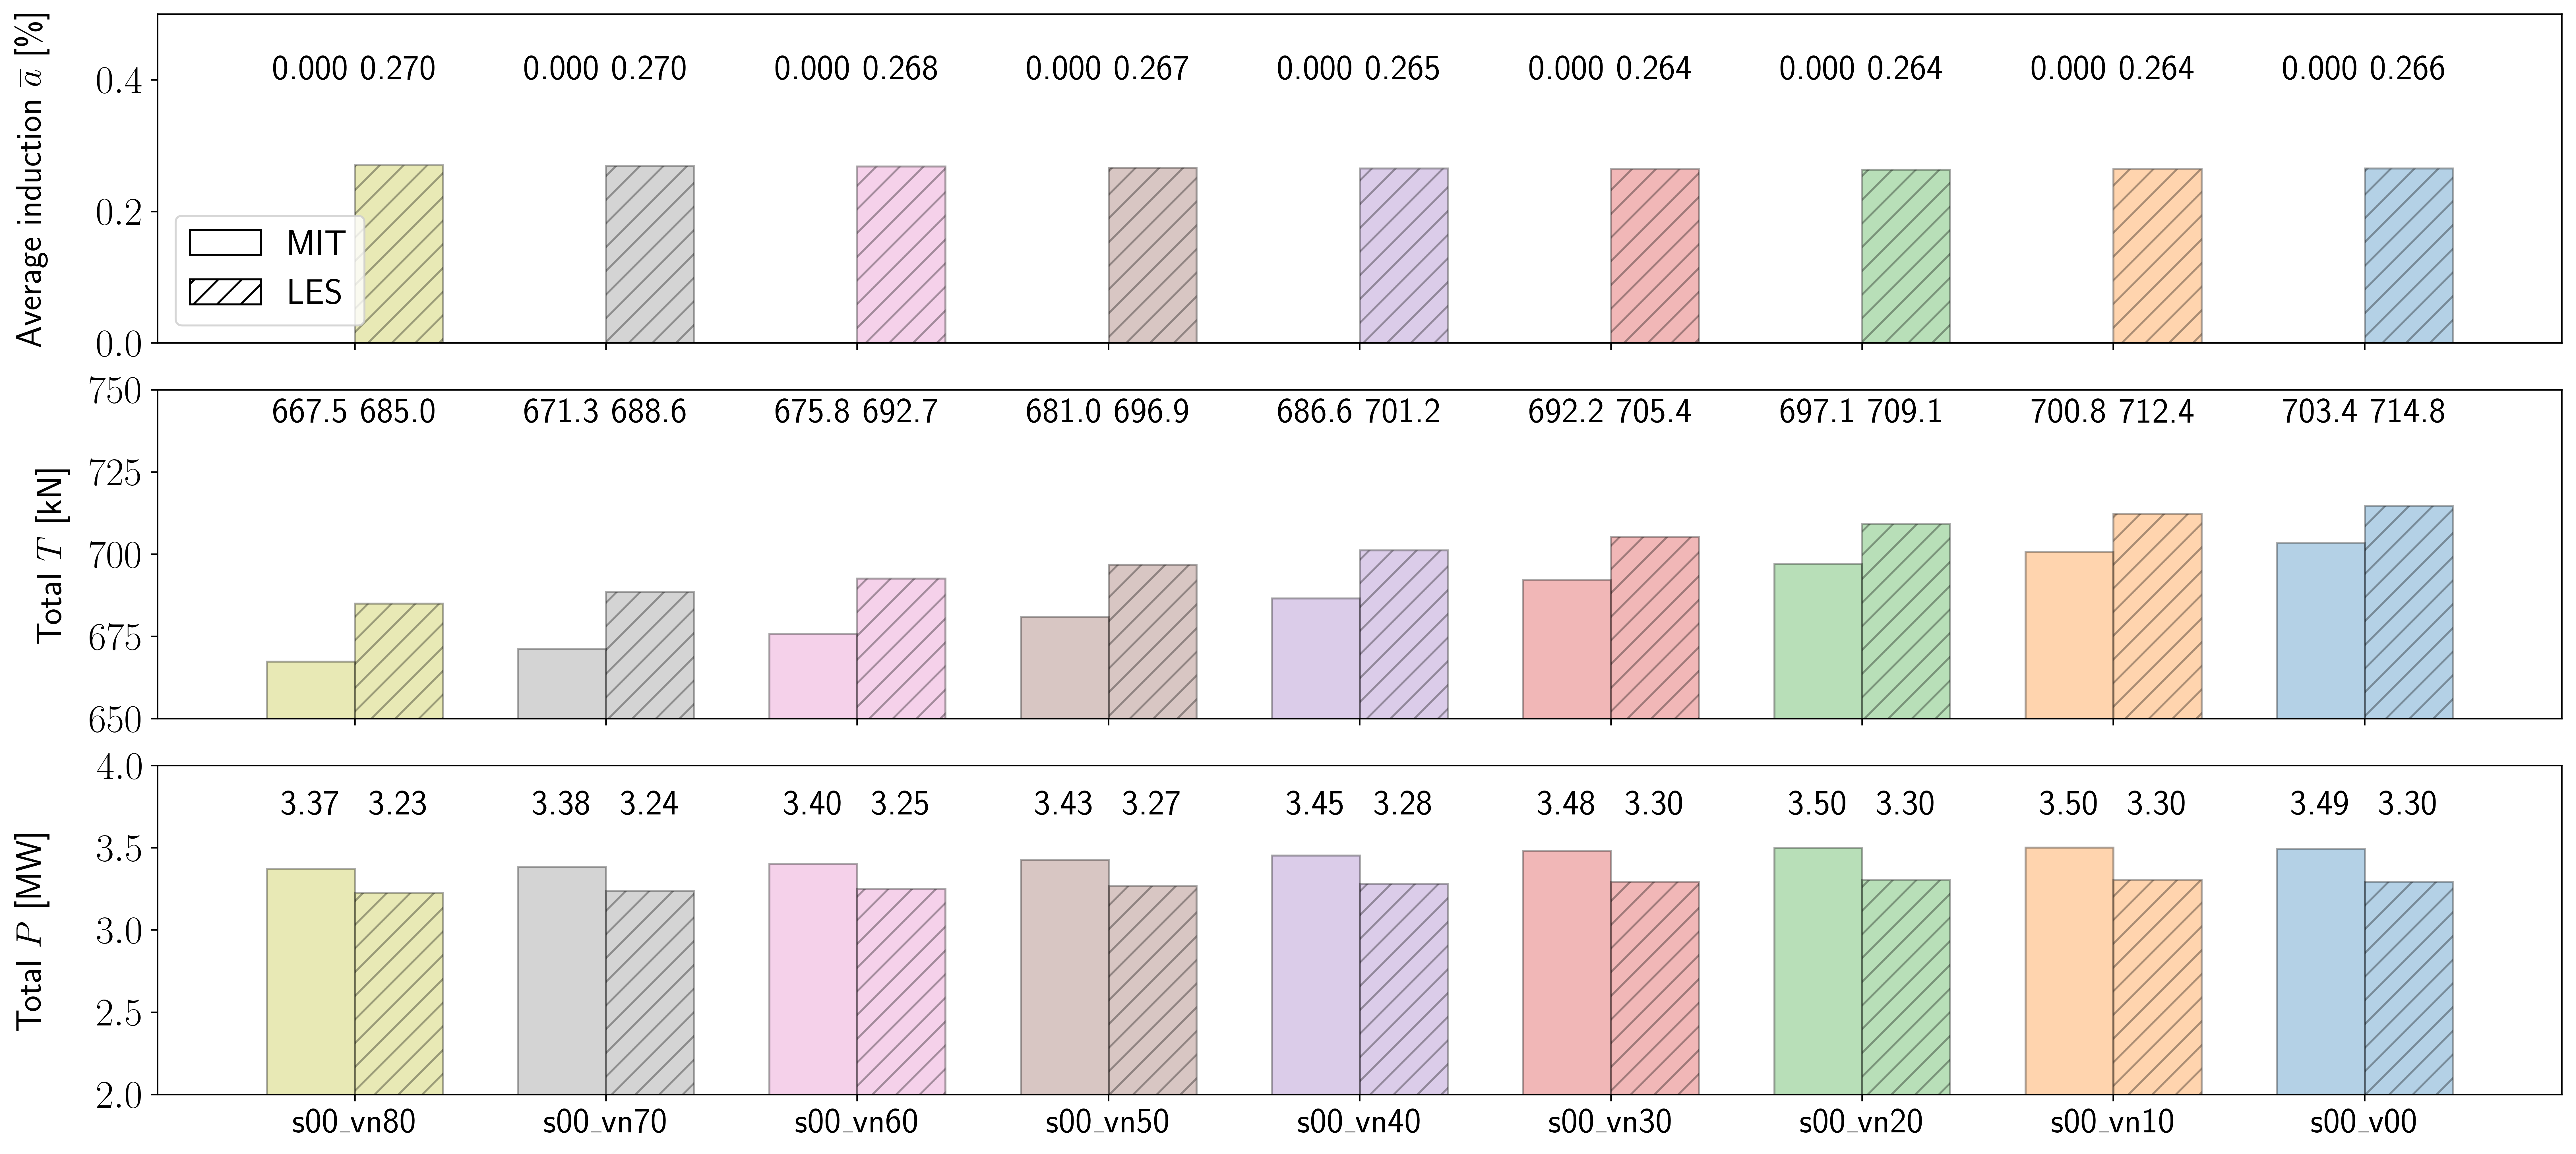

In [65]:
# Dimensional

width = 0.35
alpha = 1/3
fontsize = 18

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Induction

    ax[0].bar(ind[count] - width/2, mit_ind[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_ind_ss[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 0.4,
               f'{mit_ind[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].text(ind[count] + width/2, 0.4,
               f'{wrf_ind_ss[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].set_ylabel(r'Average induction $\overline{a}$ [\%]', fontsize=fontsize, labelpad=24)
    ax[0].set_ylim([0, 0.5])

    # --- Thrust

    ax[1].bar(ind[count] - width/2, mit_thr[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thr_ss[count]/1e3, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 740,
               f'{mit_thr[count]:0.1f}%', ha='center', fontsize=fontsize)
    
    ax[1].text(ind[count] + width/2, 740,
               f'{wrf_thr_ss[count]/1e3:0.1f}%', ha='center', fontsize=fontsize)
    
    ax[1].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize, labelpad=10)
    ax[1].set_ylim([650, 750])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_pow[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_pow_ss[count]/1e6, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, 3.7,
               f'{mit_pow[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].text(ind[count] + width/2, 3.7,
               f'{wrf_pow_ss[count]/1e6:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize, labelpad=24)
    ax[2].set_ylim([2, 4])

# Final formatting
ax[2].set_xticks(ind)
ax[2].set_xticklabels(new_names, fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='MIT'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

# Add legend to the top plot
ax[0].legend(handles=legend_handles, fontsize=fontsize, loc='lower left')

plt.show()
